# Fractional Brownian Motion Using Variance Ratio Tests

Consider a sample of $t$ measurements,

$
\begin{align}
X_0, X_1, X_2, \ldots, X_t
\end{align}
\tag{1}
$

A test is desired to determine if the series represents brownian motion, which is defined by,

$
\begin{align}
X_t = \sum_{i=1}^t X_i - X_{i-1} = \sum_{i=1}^t \Delta X_{i}
\end{align}
\tag{2}
$

where $\Delta X_i$ are independent and identically distributed with distribution,

$
\begin{align}
\Delta X_i \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{3}
$

and

$
\begin{align}
\text{Cov}(\Delta X_i \Delta X_j) = \sigma^2 \delta_{ij}
\end{align}
\tag{4}
$

This is the homoscedasticity assumption. Consider the difference,

$
\begin{align}
\Delta X_i(s) = X_i - X_{i+s}
\end{align}
\tag{5}
$

So that,

$
\begin{align}
X_t = \sum_{i=1}^n \Delta X_i(s)
\end{align}
\tag{6}
$

with $t=ns$. Let, 

$
\begin{align}
\sigma^2(s) = \text{Var}\left(\Delta X_i (s) \right)
\end{align}
\tag{7}
$

Recall for brownian motion $\sigma_B^2(t) = \sigma^2t$, it follows that $\sigma^2_B(s) = \sigma^2(1)s$. Consider the ratio,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
\tag{8}
$

where,

$
\begin{align}
&\sigma^2(1) = \frac{1}{t-1} \sum_{i=1}^t \left(X_i - X_{i-1} - \mu \right) \\
&\mu = \frac{1}{t} \left( X_t - X_0 \right)
\end{align}
\tag{9}
$

In Lo and Mackinlay, 1988, "Stock market Prices do not Follow Random Walks" it was shown that an unbiased estimator of $\sigma^2(s)$ is given by,

$
\begin{align}
\sigma^2(s) = \frac{1}{m} \sum_{i=s}^t \left( X_t - X_{t-s} - s\mu \right)^2
\end{align}
\tag{10}
$

where,

$
\begin{align}
m = \left(t - s + 1 \right) \left( 1 - \frac{s}{t} \right)
\end{align}
\tag{11}
$

If $X_t$ is brownian motion, $\sigma^2(s) = \sigma^2(1)$, $s = \sigma^2_B(s)$. It follows that $\text{VR}(s) = 1$. A test statistic for this condition is given by,

$
\begin{align}
Z(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta(s)}}
\end{align}
\tag{12}
$

where,

$
\begin{align}
\theta(s) = \frac{2\left( 2s - 1 \right)\left( s - 1 \right)}{3st}
\end{align}
\tag{13}
$

and $Z(s) \sim \text{Normal}(0,1)$. This test-statistic was derived assuming homoscedasticity which implies that the random component is independent of $s$. If instead the random component varies with $s$ heteroscedasticity is assumed.

For this case the test-statistic is given by,

$
\begin{align}
Z^\ast(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta^\ast (s)}}
\end{align}
\tag{14}
$

where,

$
\begin{align}
&\theta^\ast (s) = \sum_{j=1}^{s-1} \left[ \frac{2\left( s - j \right) } {s} \right]^2 \hat{\delta}(j) \\
&\hat{\delta}(j) = \frac{\sum_{i=j+1}^t \left( X_i - X_{i-1} - \mu \right)^2 \left( X_{i-j} - X_{i-j-1} - \mu \right)^2}{\left[ \sum_{i=1}^t \left( X_i - X_{i-1} - \mu \right)^2 \right]^2}
\end{align}
\tag{15}
$

The significance test using $Z(s)$ and $Z^\ast(s)$ succeeds if the time series is brownian motion. This test is implemented using two tails and the series is brownian motion if it succeeds. A test for $H<0.5$ uses a lower tail test and succeeds if the test for brownian motion fails. Similarly, A test for $H>0.5$ would use an upper tail test and succeed if the test for brownian motion fails.

## Import

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats, HypothesisTestType
from lib.plots import fpoints, comparison, curve, variance_ratio_test, PlotType
from lib.utils import create_parameter_scan, apply_to_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def create(H_vals, npts):
    params = [{"H": H, "npts": npts} for H in H_vals]
    source = lambda **kwargs: fbm.create_fft_source(**kwargs)
    return create_parameter_scan(source, *params)

def lag_var_plot(samples, H, npts):
    title = f"Simulated FBM Lagged Variance: H={H}"
    labels = [r"$\sigma^2(s)$", r"$s^{2H}$"]
    s_vals, lag_var = stats.compute_lag_var(samples, smax=npts/10, npts=100)
    t, fbm_var = fbm.compute_var(numpy.array(s_vals)[::5], H=H)
    fpoints(data=lag_var, func=fbm_var, x=s_vals, fx=t, plot_axis_type=PlotType.LOG, title=title, labels=labels, xlabel=r"$s$", ylabel=r"$\sigma^2(s)$")

def vr_plot(samples, H, npts):
    title = f"Simulated FBM Variance Ratio: H={H}"
    labels = [r"VR$(s)$", r"$s^{2H-1}$"]
    s_vals, vr = fbm.compute_vr_scan(samples, smax=npts/10, npts=100)
    t, fbm_vr = fbm.compute_vr(numpy.array(s_vals)[::5], H=H)
    fpoints(data=vr, func=fbm_vr, x=s_vals, fx=t, title=title, labels=labels, plot_axis_type=PlotType.LOG, xlabel=r"$s$", ylabel=r"VR$(s)$")
    
def homo_test_stat_plot(report, H):
    title = f"Homoscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)

def hetero_test_stat_plot(report, H):
    title = f"Heteroscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)
    
def H_labels(H_vals):
    return [f"H={format(H, '1.2f')}" for H in H_vals]

## $\sigma^2 (s)$ and $\text{VR}(s)$ Verification

The $\sigma^2 (s)$ calculation is verified by comparing with $s^{2H}$. The variance ratio is given by,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
$

Since $\sigma^2(s) \sim s^{2H}$ and $\sigma_B^2(s) \sim s$ it follows that $\text{VR}(s) \sim s^{2H - 1}$.

In [3]:
npts = 2**16
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

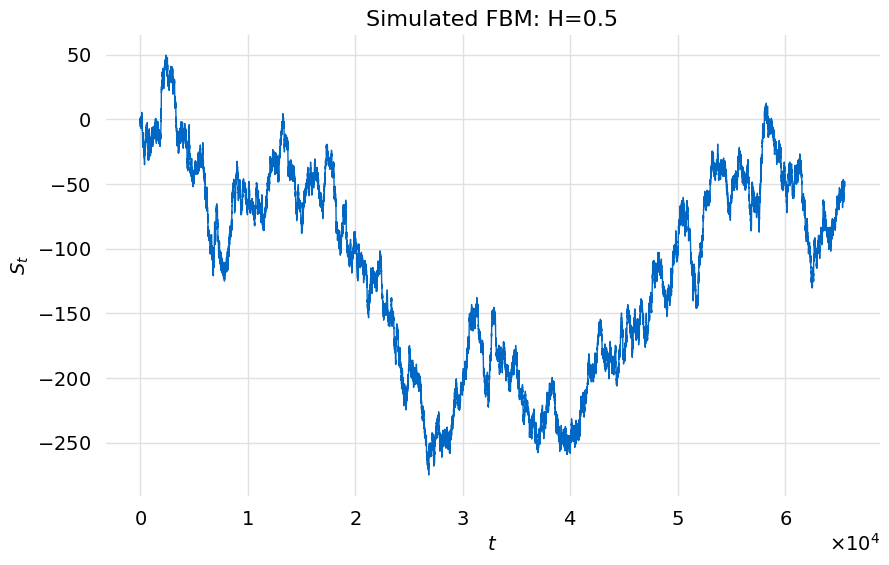

In [4]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

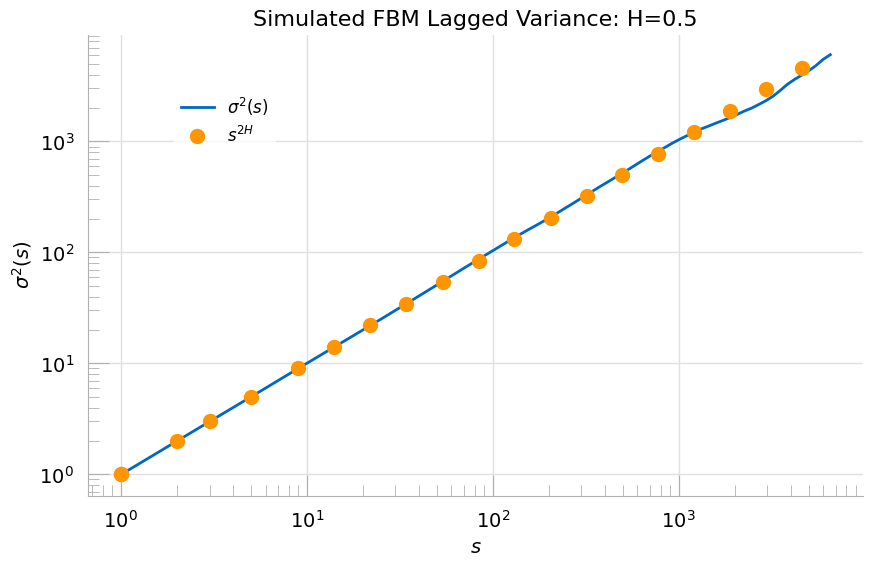

In [5]:
lag_var_plot(samples[0], H_vals[0], npts)

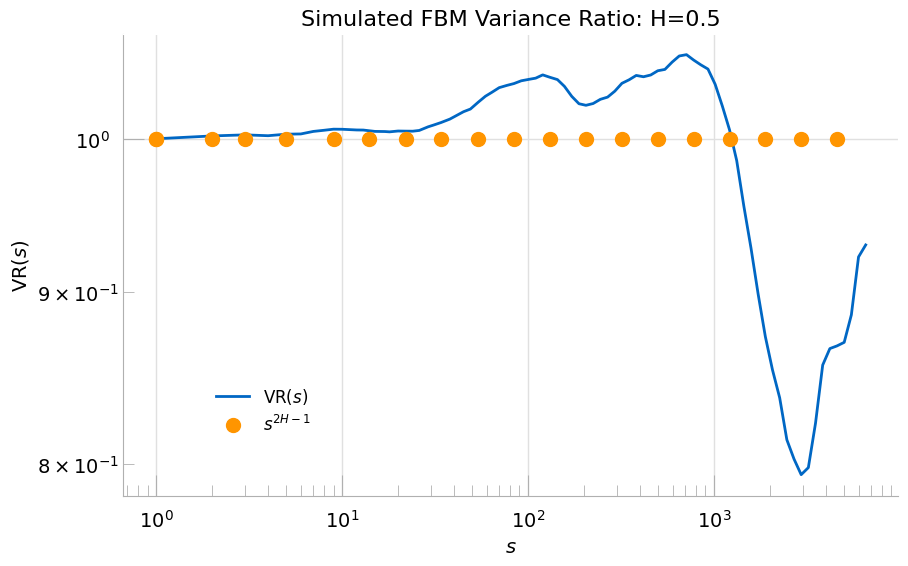

In [6]:
vr_plot(samples[0], H_vals[0], npts)

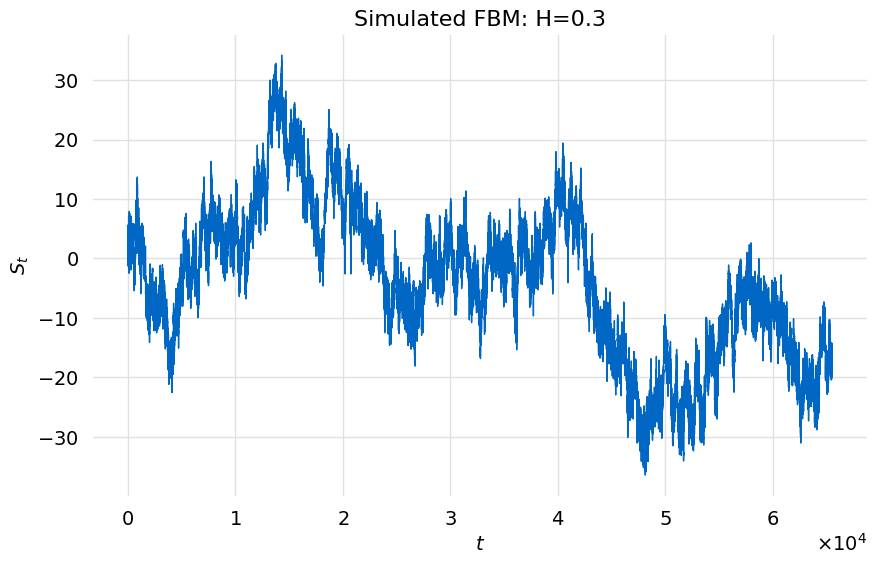

In [7]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

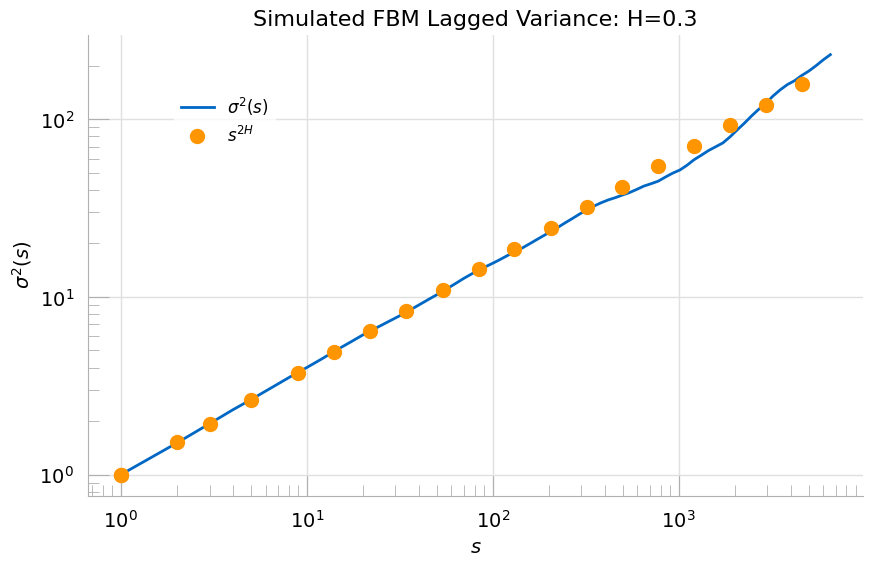

In [8]:
lag_var_plot(samples[1], H_vals[1], npts)

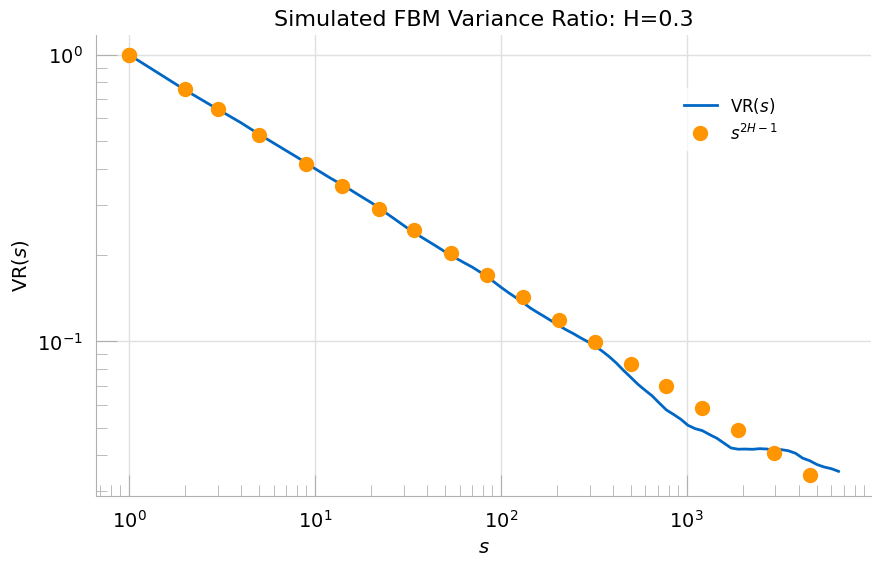

In [9]:
vr_plot(samples[1], H_vals[1], npts)

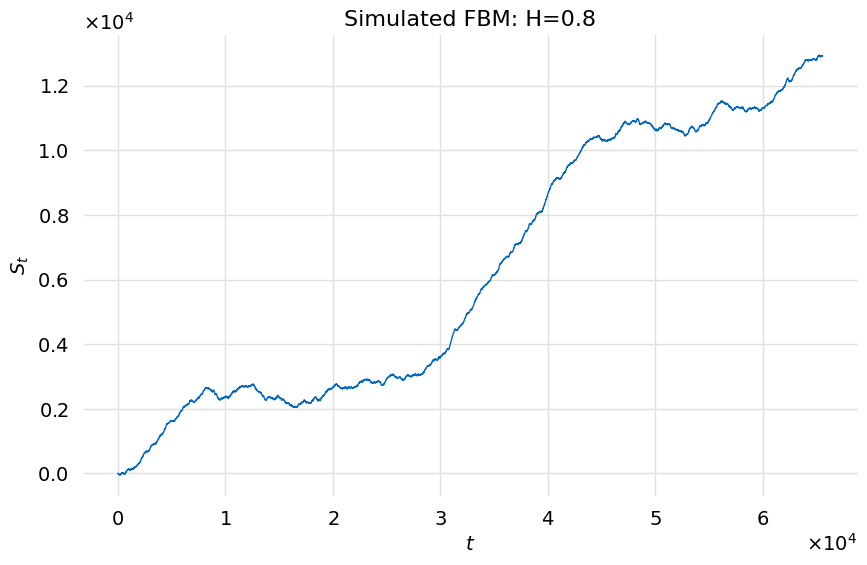

In [10]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

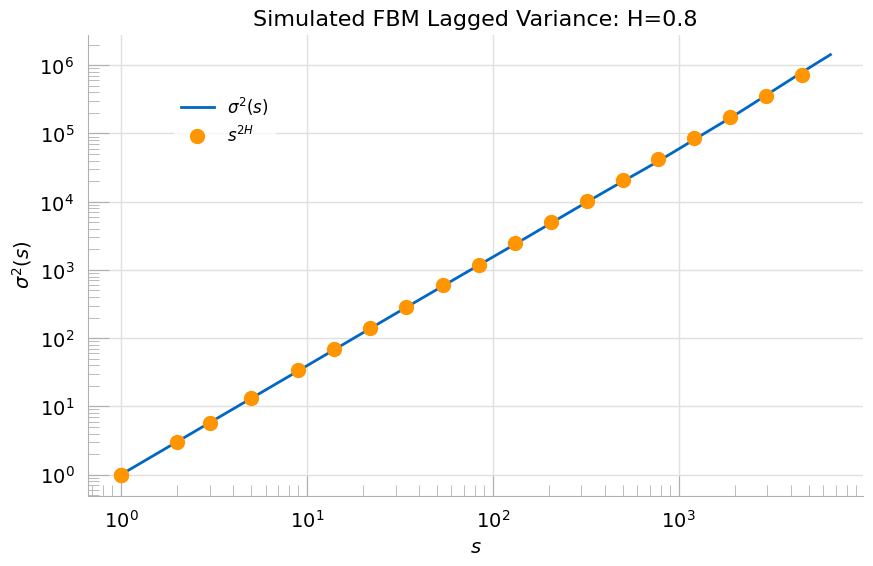

In [11]:
lag_var_plot(samples[2], H_vals[2], npts)

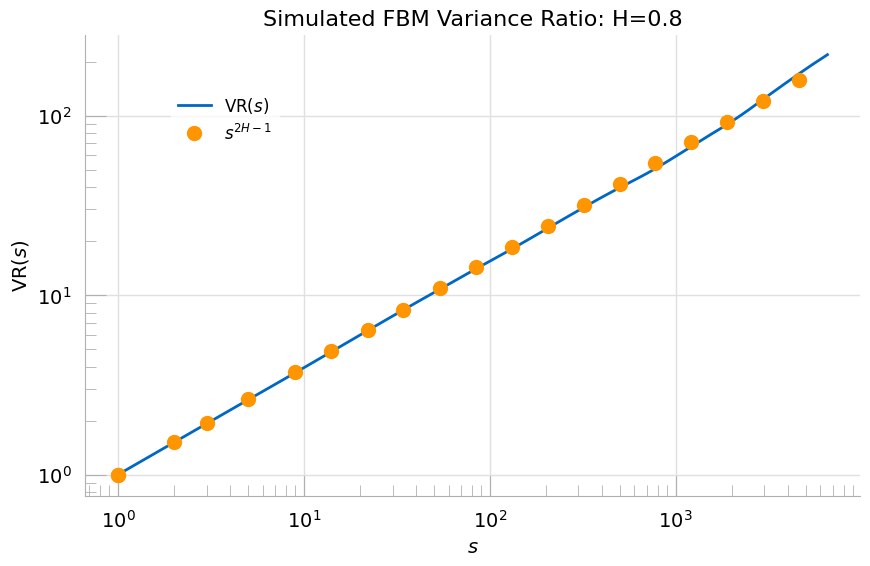

In [12]:
vr_plot(samples[2], H_vals[2], npts)

## Small Sample Size

In the previous verification section a rather large sample size was used to provide enough data to compute accurate averages. In general</br>
this is not practical. here more realistic sample sizes are used to see the impact on the analysis. 

In [13]:
npts = 2**9
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

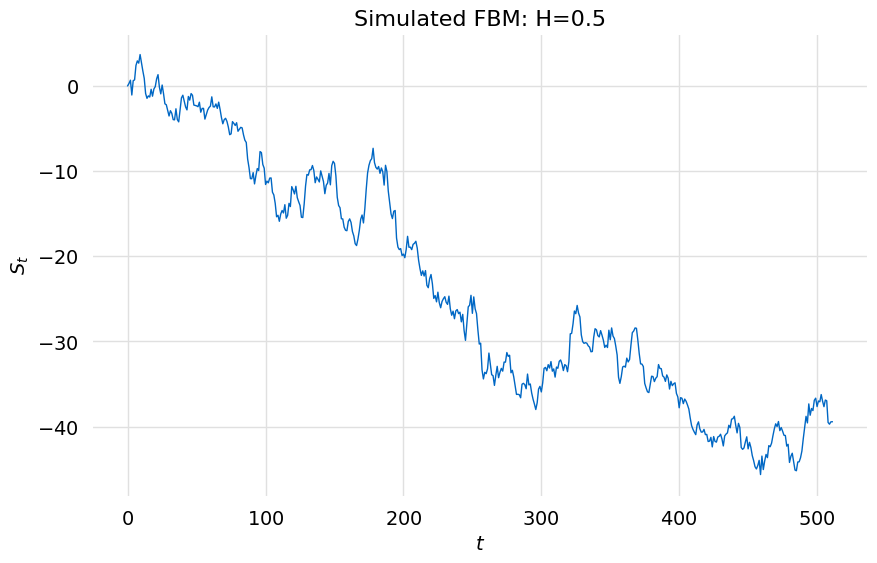

In [14]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

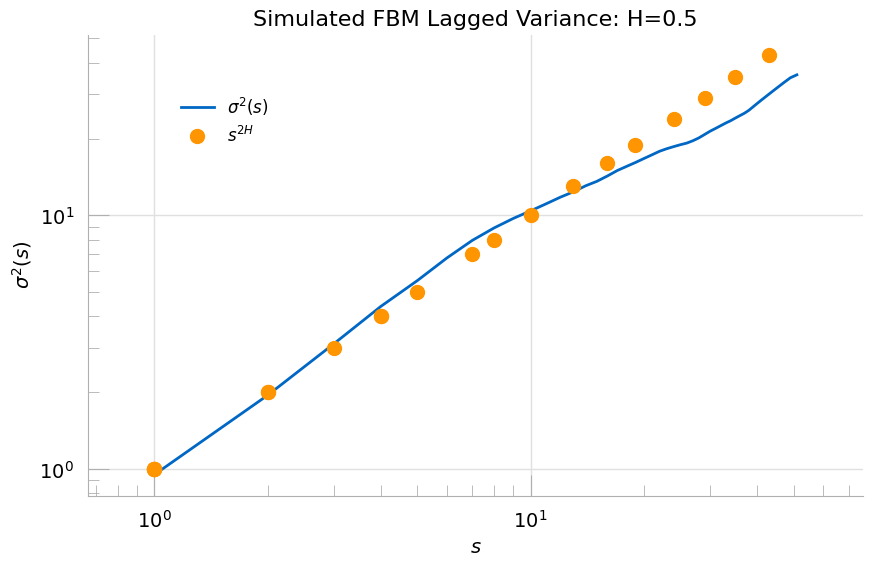

In [15]:
lag_var_plot(samples[0], H_vals[0], npts)

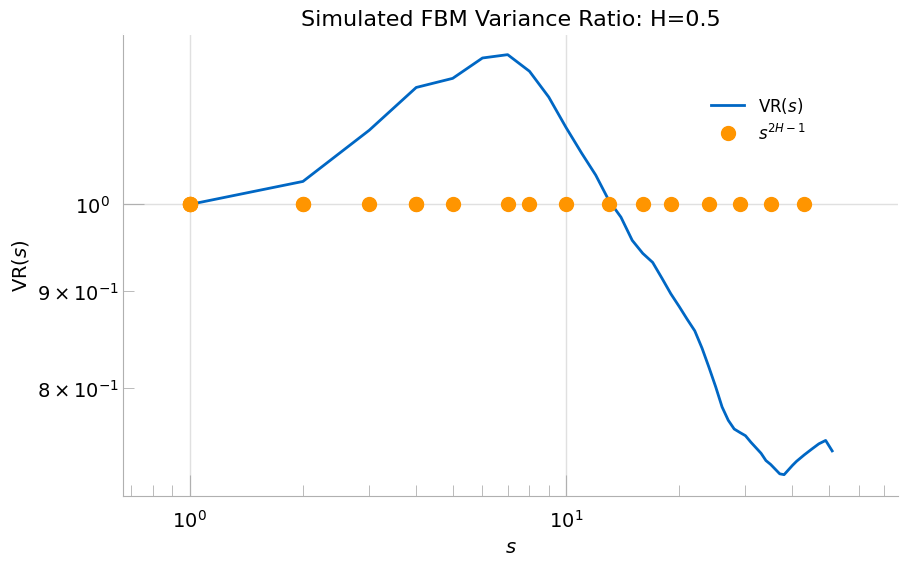

In [16]:
vr_plot(samples[0], H_vals[0], npts)

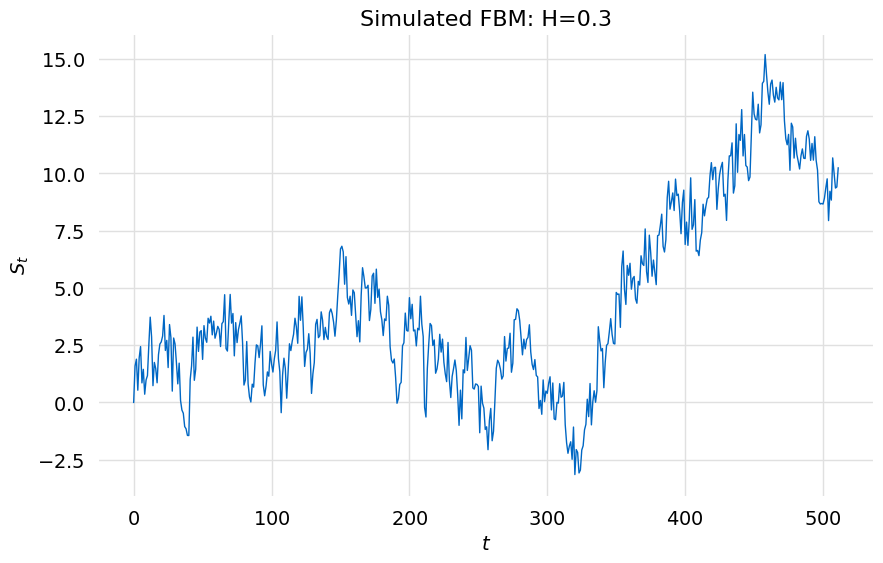

In [17]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

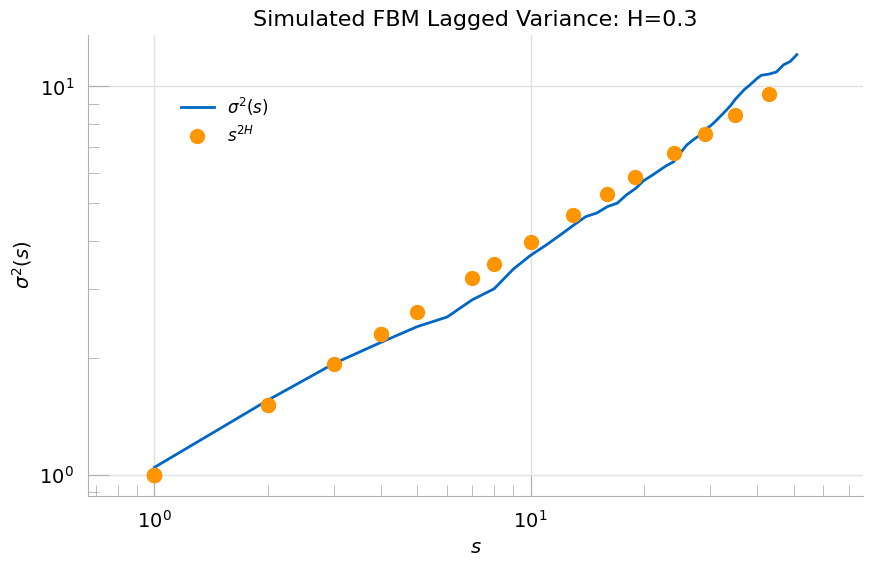

In [18]:
lag_var_plot(samples[1], H_vals[1], npts)

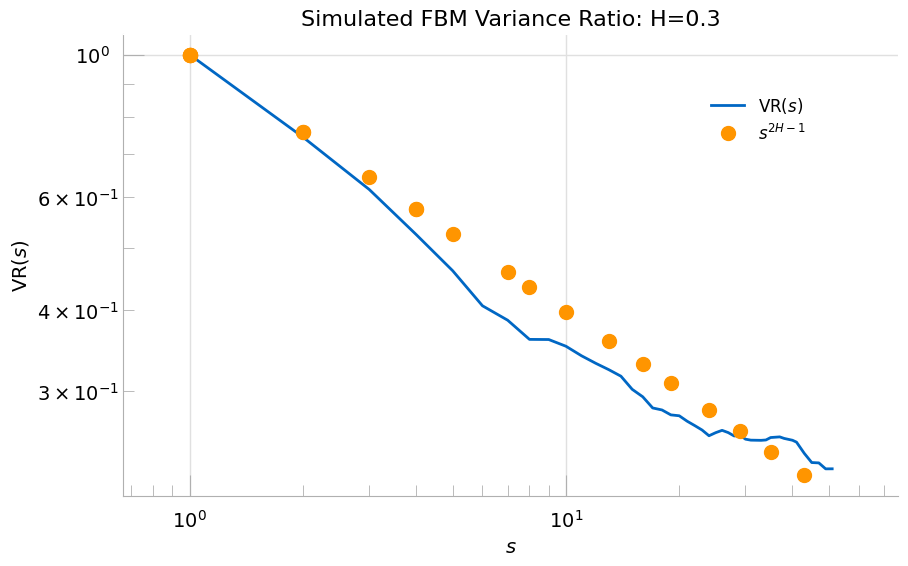

In [19]:
vr_plot(samples[1], H_vals[1], npts)

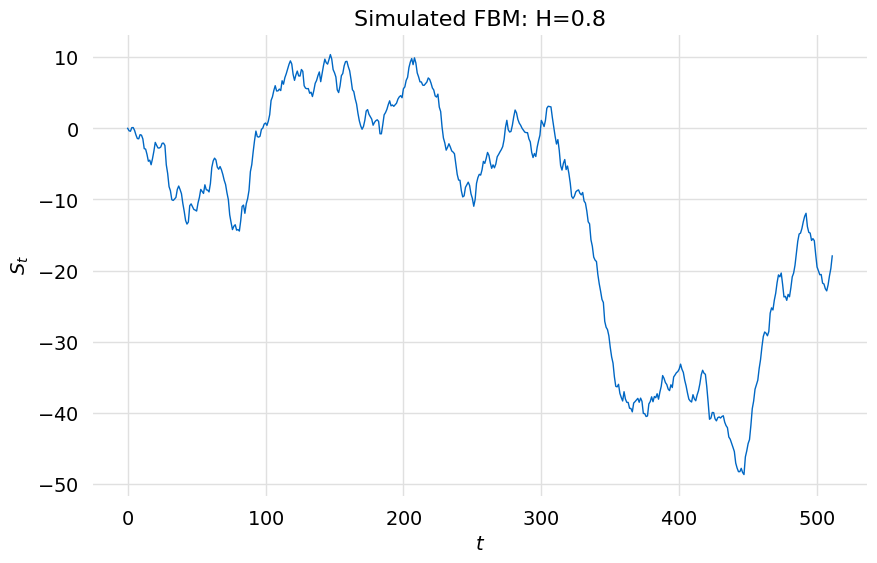

In [20]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

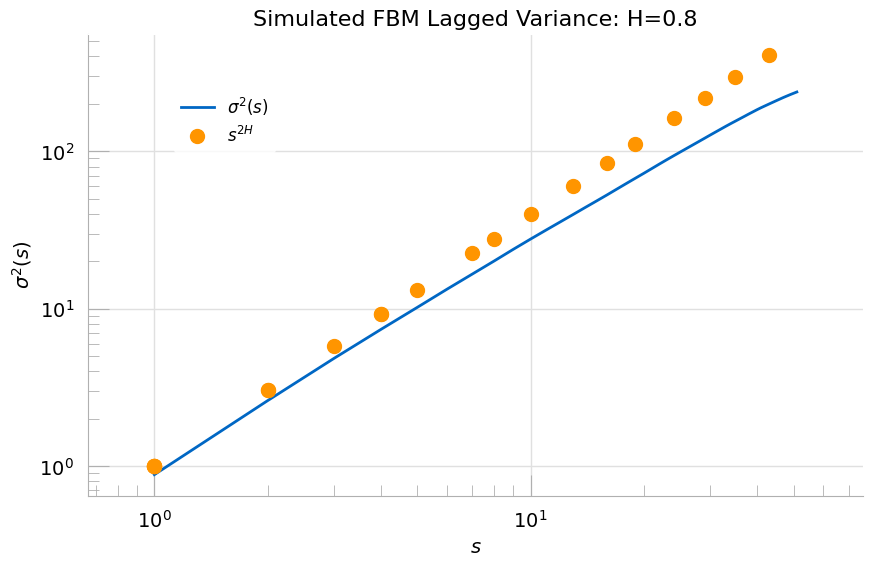

In [21]:
lag_var_plot(samples[2], H_vals[2], npts)

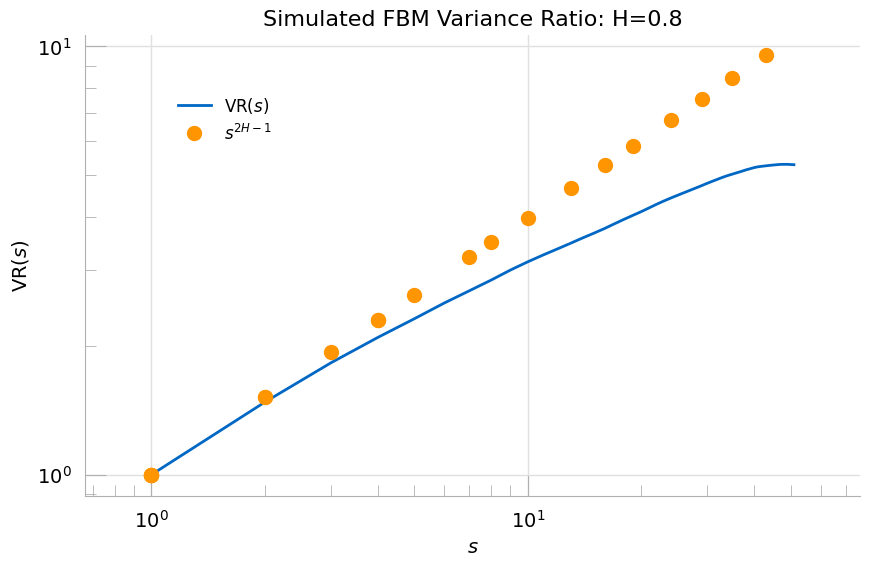

In [22]:
vr_plot(samples[2], H_vals[2], npts)

## Variance Ratio Test Comparison

In this section simulations that test the homoscedastic and heteroscedastic variance ratio test statistic are presented. It is seen that the results are not</br>
significantly different despite the greater cost of the heteroscedastic calculation. First large time series are</br>
analyzed followed by more realistic series lengths. A range of $H$ values is used.

In [23]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.5, 0.3, 0.7]
t, samples = create(H_vals, npts)

### H = 0.5 

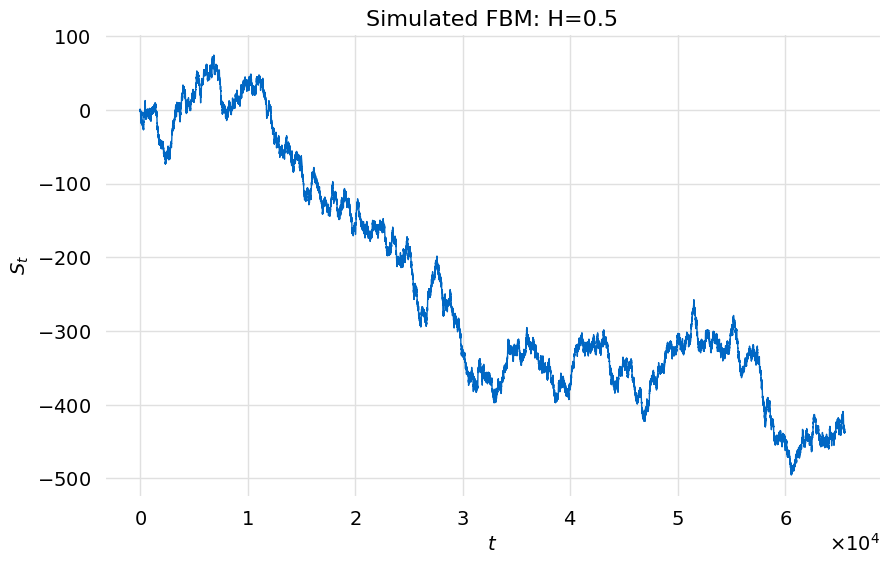

In [24]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [25]:
report, result = fbm.compute_vr_test(samples[0], HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.902 │    0.367 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.689 │    0.491 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.642 │    0.521 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.581 │    0.561 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [26]:
result.dict

{'Status': True,
 'HypothesisType': <HypothesisType.TWO_TAIL: 'TWO_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.BM: 'BM'>,
 'Description': 'Brownian Motion Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': -0.9023790663750784, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.36685553740508414, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s)$'}},
  {'Status': True,
   'Statistic': {'Value': -0.6891364931197083, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.49073737688503116, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s

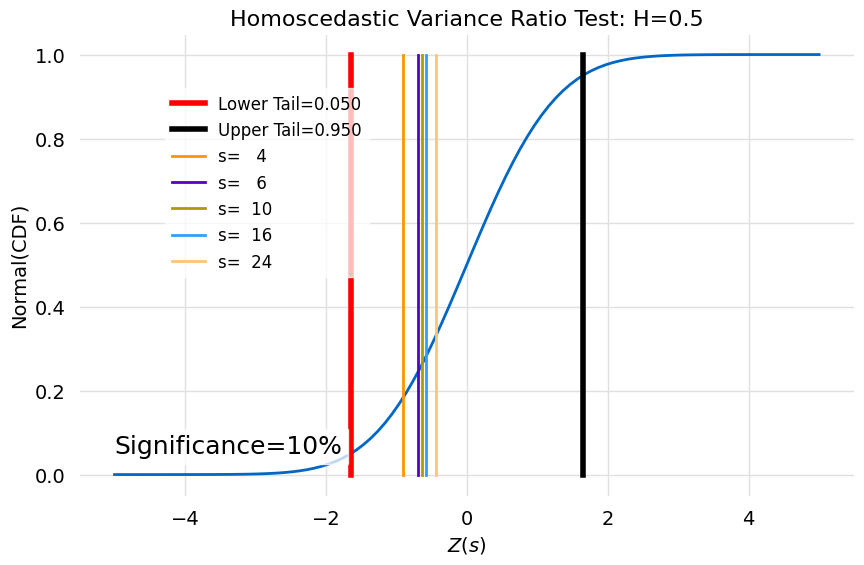

In [27]:
homo_test_stat_plot(report, H_vals[0])

In [28]:
report, result = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -0.9   │    0.368 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -0.688 │    0.492 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.641 │    0.521 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.581 │    0.561 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [29]:
result.dict

{'Status': True,
 'HypothesisType': <HypothesisType.TWO_TAIL: 'TWO_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.BM: 'BM'>,
 'Description': 'Brownian Motion Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': -0.9000027512176043, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.36811878657848407, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s)$'}},
  {'Status': True,
   'Statistic': {'Value': -0.6875383397390918, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.4917435490724942, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s)

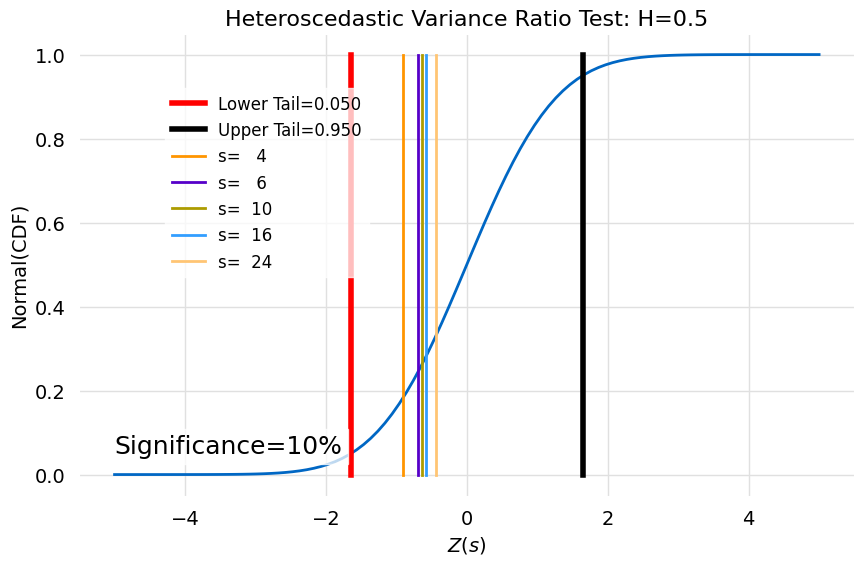

In [30]:
hetero_test_stat_plot(report, H_vals[0])

### H = 0.3

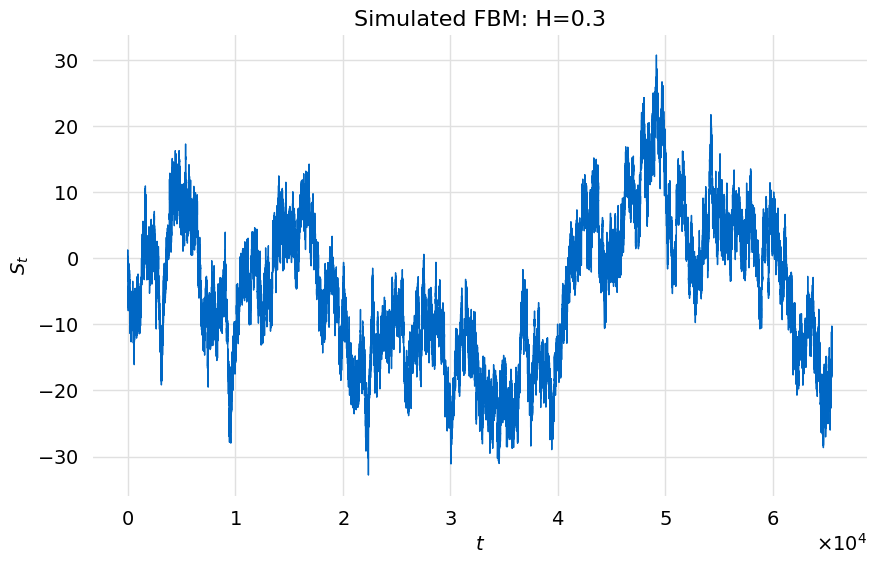

In [31]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [32]:
report, result = fbm.compute_vr_test(samples[1], HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -57.465 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -52.116 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -44.889 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.449 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

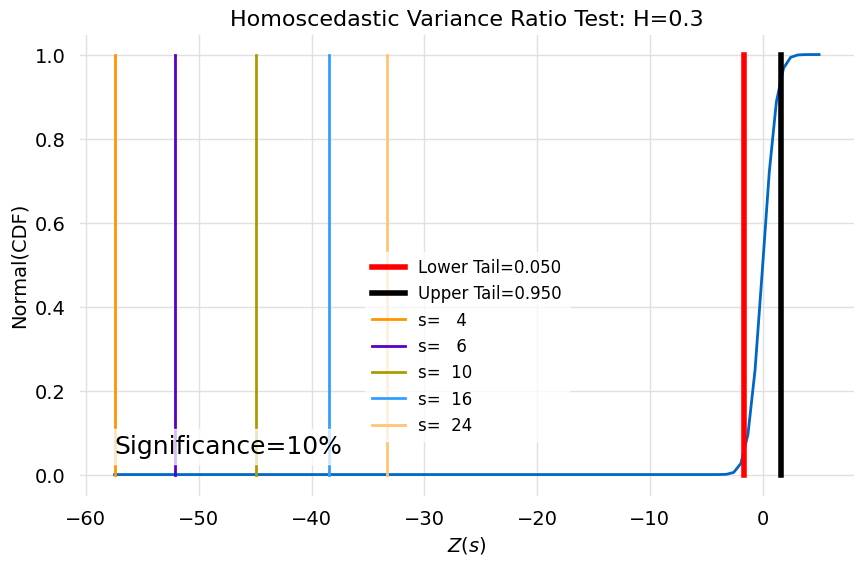

In [33]:
homo_test_stat_plot(report, H_vals[1])

In [34]:
report, result = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -55.256 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -50.662 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -44.079 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.003 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

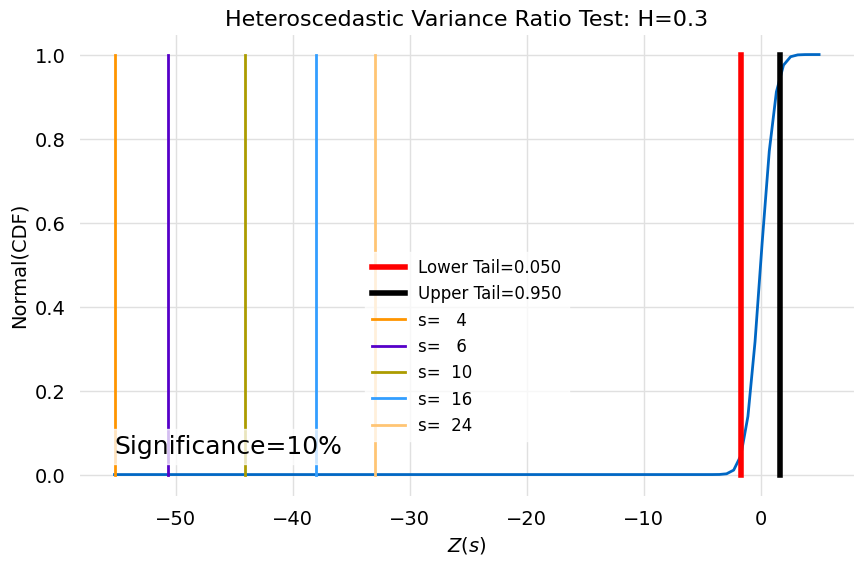

In [35]:
hetero_test_stat_plot(report, H_vals[1])

### H=0.7

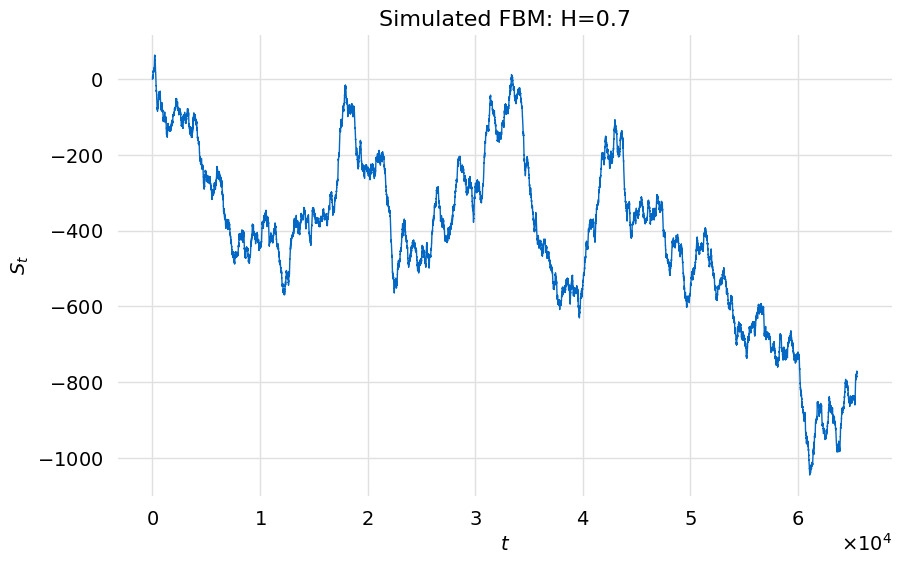

In [36]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [37]:
report, result = fbm.compute_vr_test(samples[2], HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ 102.49  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 109.053 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 114.039 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 116.576 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

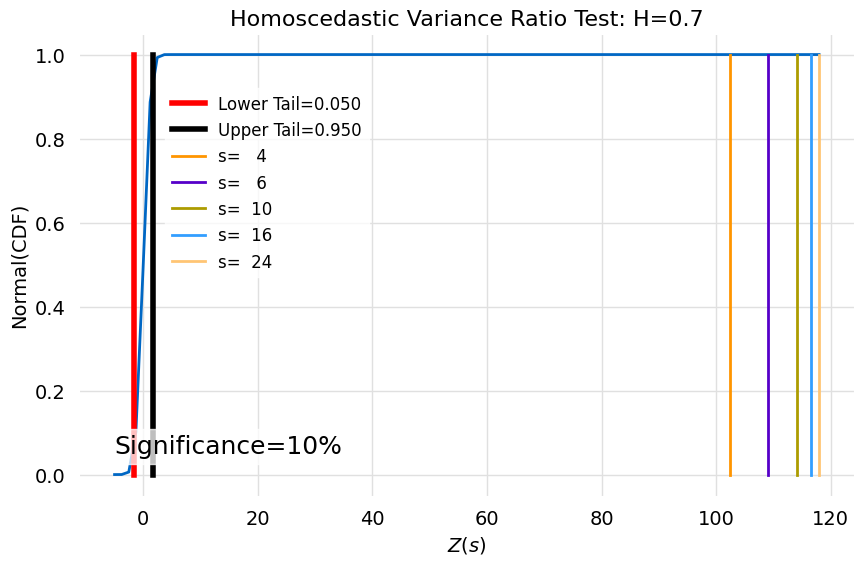

In [38]:
homo_test_stat_plot(report, H_vals[2])

In [39]:
report, result = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │  95.492 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 103.058 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 109.535 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 113.257 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

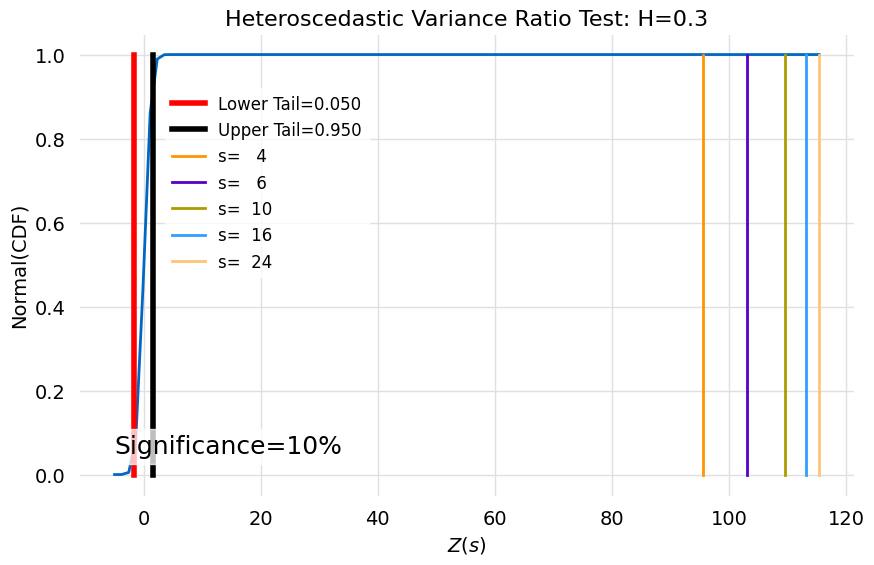

In [40]:
hetero_test_stat_plot(report, H_vals[1])

### Values Near H=0.5

The performance of the homoscedastic and heteroscedastic for values near $H=0.5$ is evaluated.

In [41]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.475, 0.49, 0.51, 0.525]
t, samples = create(H_vals, npts)

#### H=0.51

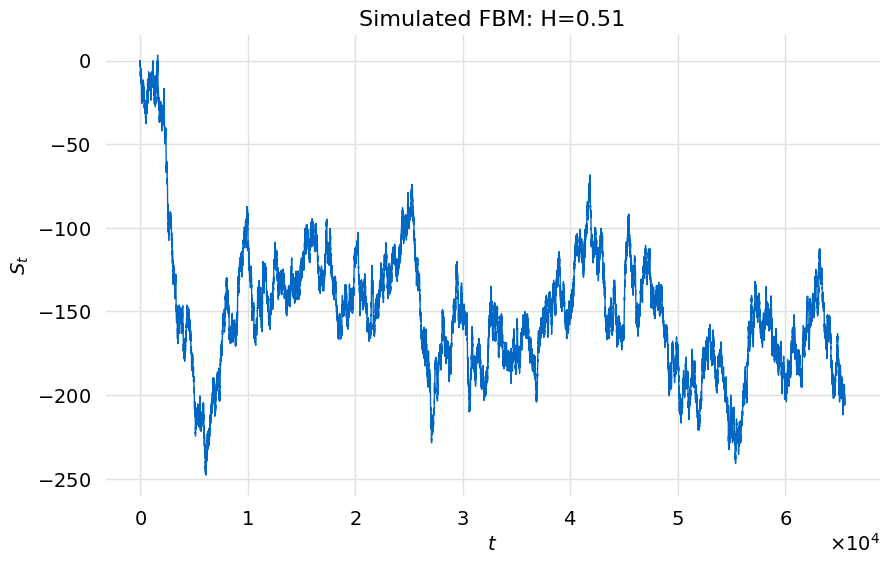

In [42]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [43]:
report, result = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  3.214 │    0.001 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  2.321 │    0.02  │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  1.86  │    0.063 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.303 │    0.762 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

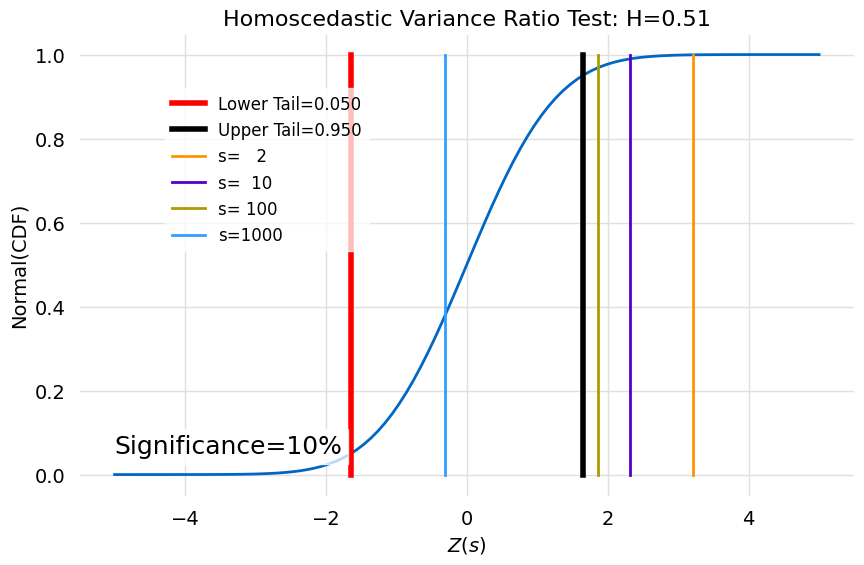

In [44]:
homo_test_stat_plot(report, H_vals[2])

In [45]:
report, result = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  3.225 │    0.001 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  2.32  │    0.02  │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  1.86  │    0.063 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.304 │    0.761 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

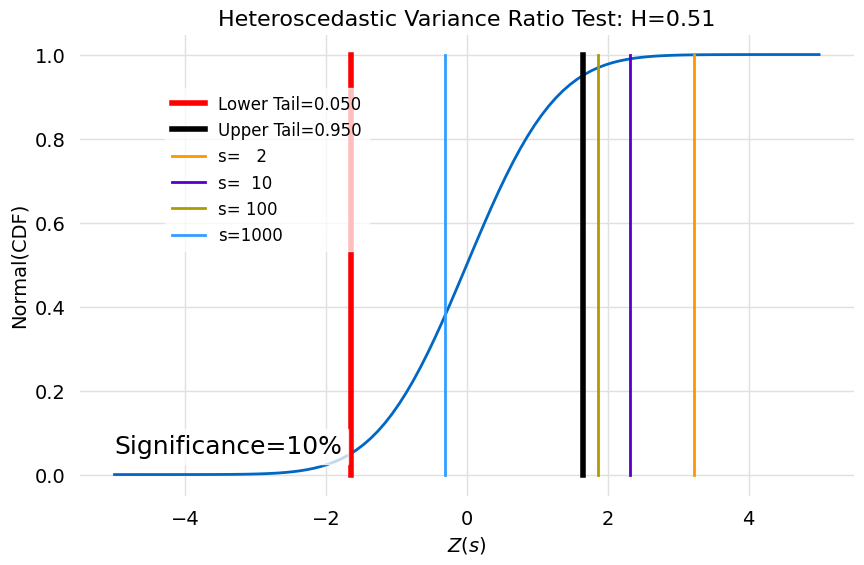

In [46]:
hetero_test_stat_plot(report, H_vals[2])

#### H=0.49

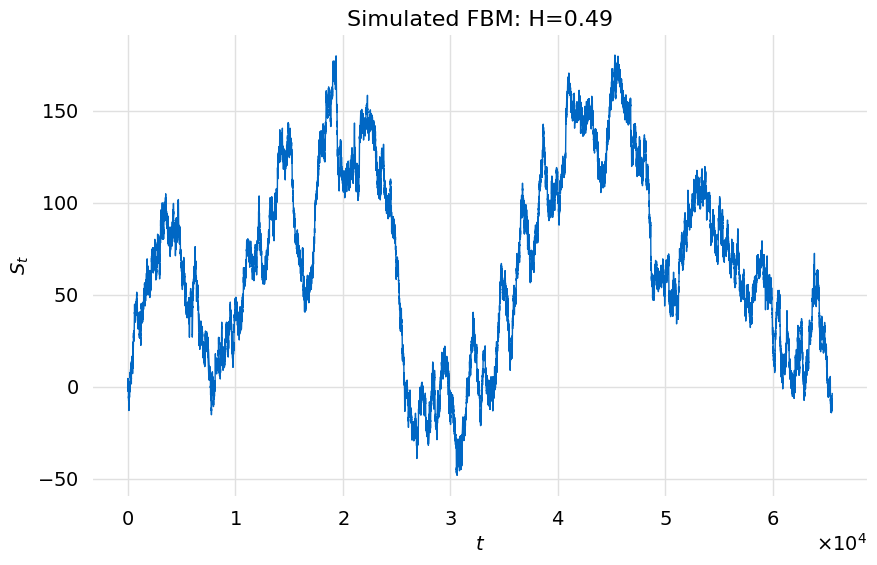

In [47]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [48]:
report, result = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -3.425 │    0.001 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -3.135 │    0.002 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -2.374 │    0.018 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.235 │    0.815 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

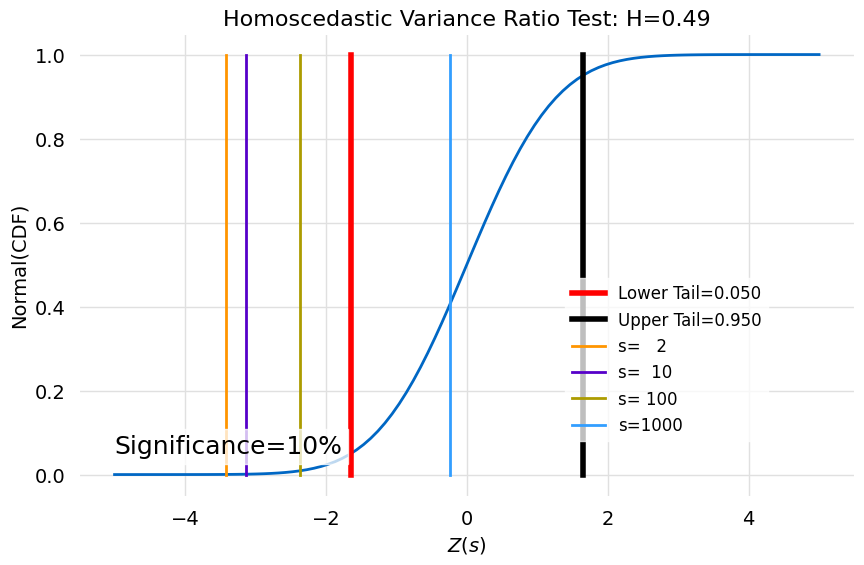

In [49]:
homo_test_stat_plot(report, H_vals[1])

In [50]:
report, result = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -3.393 │    0.001 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -3.128 │    0.002 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -2.373 │    0.018 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -0.235 │    0.814 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

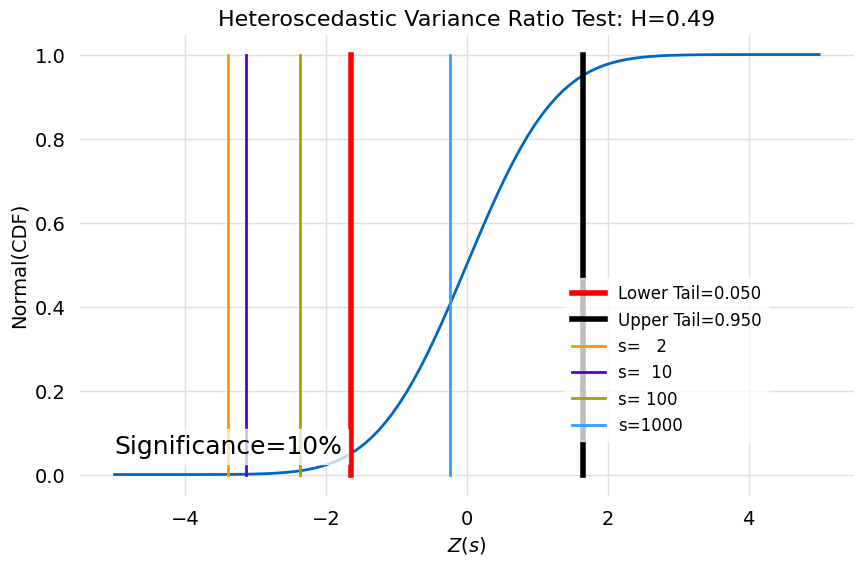

In [51]:
hetero_test_stat_plot(report, H_vals[1])

#### H=0.475

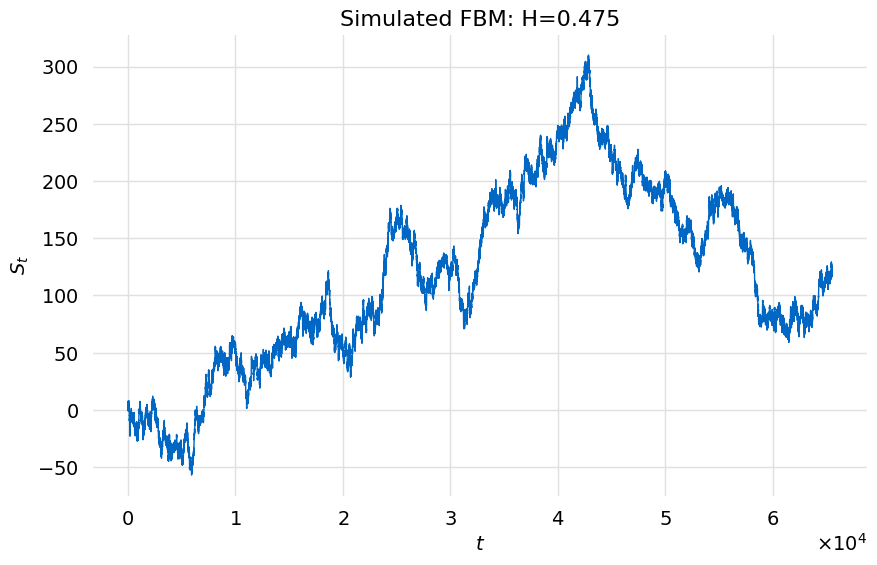

In [52]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [53]:
report, result = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -8.226 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -9.752 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -6.237 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -2.792 │    0.005 │ Failed   │
╘══════╧════════╧══════════╧══════════╛

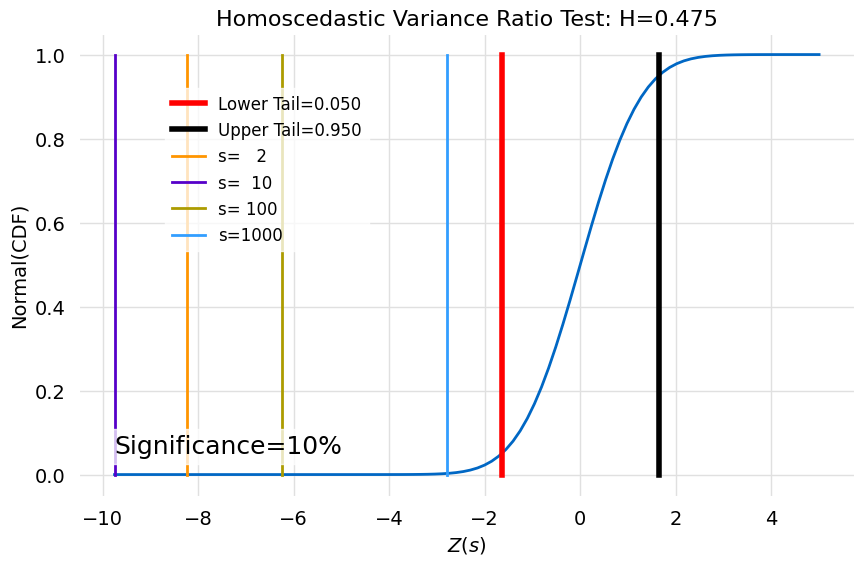

In [54]:
homo_test_stat_plot(report, H_vals[0])

In [55]:
report, result = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -8.23  │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -9.762 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -6.234 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -2.798 │    0.005 │ Failed   │
╘══════╧════════╧══════════╧══════════╛

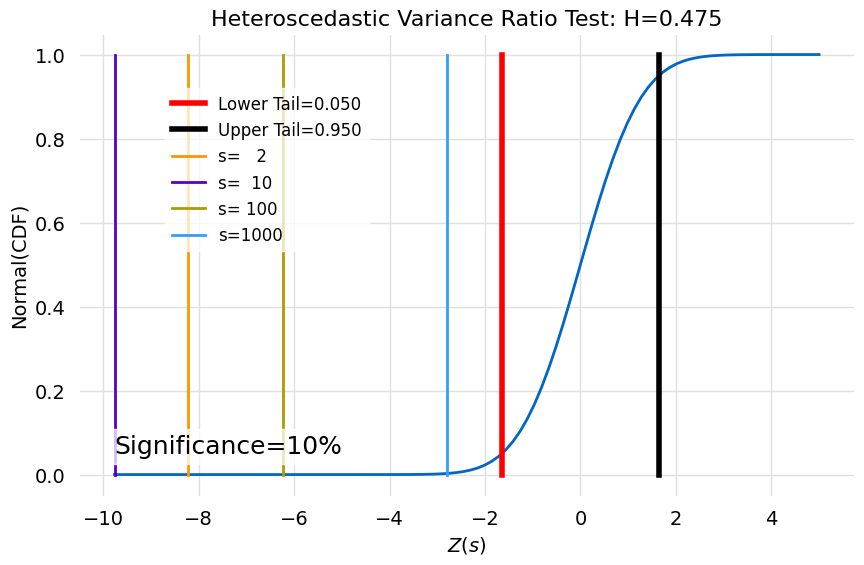

In [56]:
hetero_test_stat_plot(report, H_vals[0])

### Small Sample Size

In [57]:
npts = 2**9
s_vals = [4, 10, 25, 50, 100]
H_vals = [0.5, 0.7, 0.3]
t, samples = create(H_vals, npts)

#### H=0.5

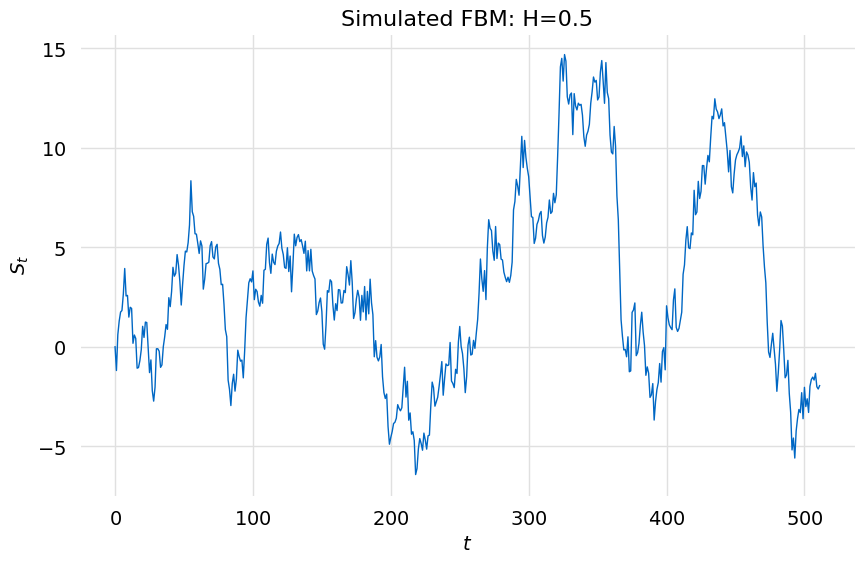

In [58]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [59]:
report, result = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.109 │    0.913 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.877 │    0.38  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.886 │    0.376 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0.785 │    0.432 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -0

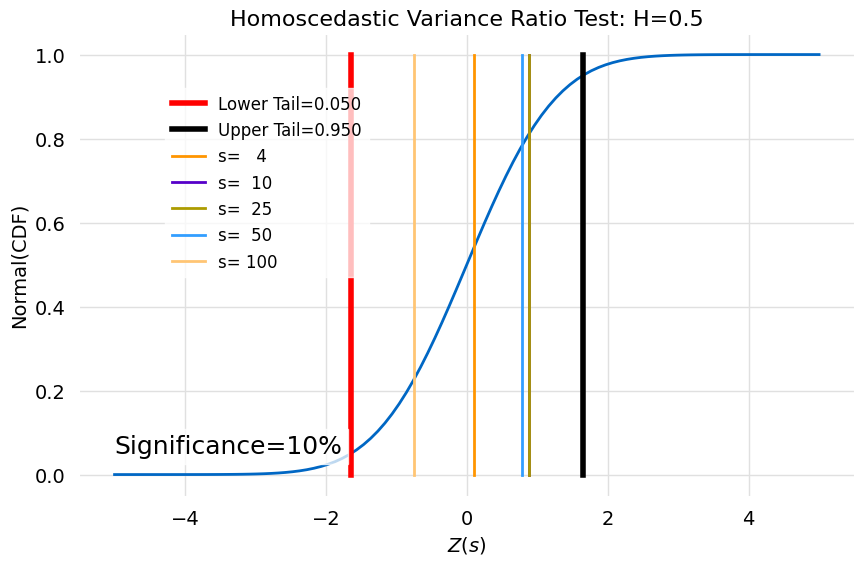

In [60]:
homo_test_stat_plot(report, H_vals[0])

In [61]:
report, result = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.105 │    0.917 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.858 │    0.391 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.874 │    0.382 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0.785 │    0.433 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -0

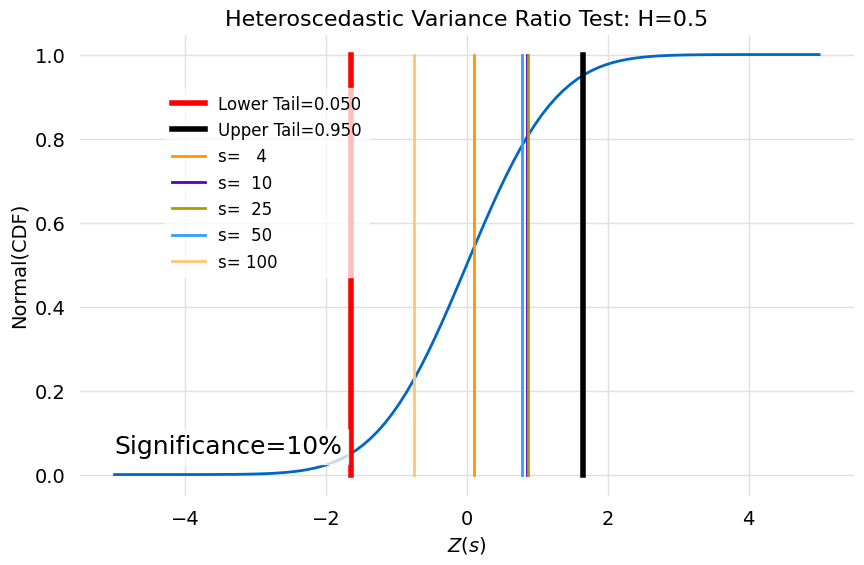

In [62]:
hetero_test_stat_plot(report, H_vals[0])

#### H=0.7

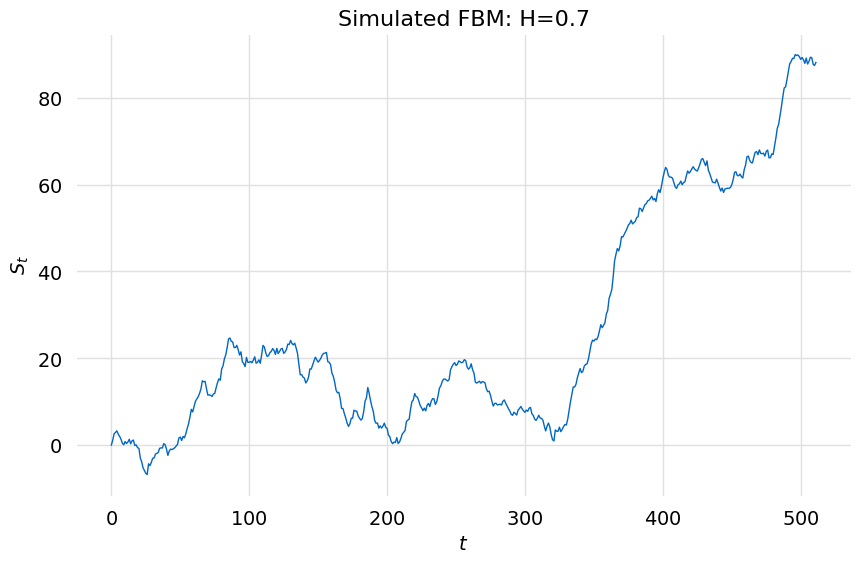

In [63]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [64]:
report, result = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ 10.651 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ 12.712 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ 11.866 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ 13.027 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  9

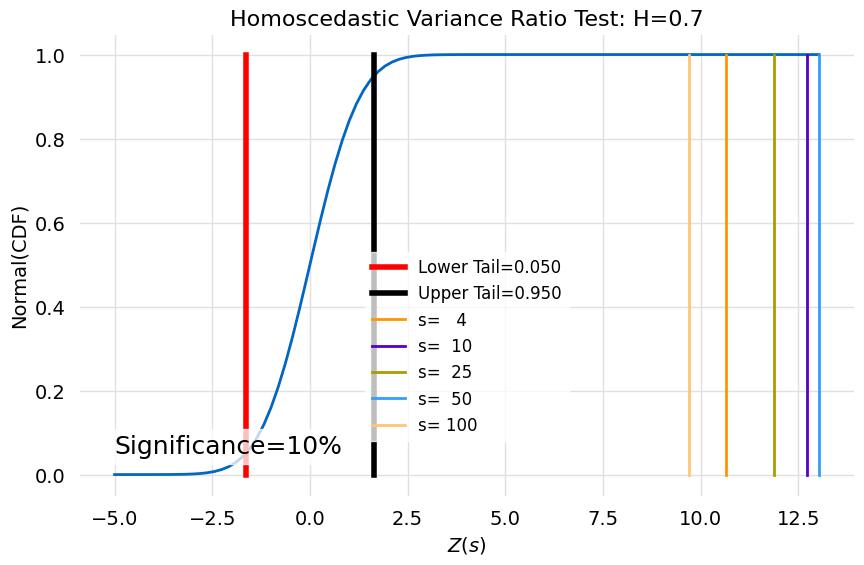

In [65]:
homo_test_stat_plot(report, H_vals[1])

In [66]:
report, result = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  9.473 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ 11.619 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ 11.459 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ 12.914 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │  9

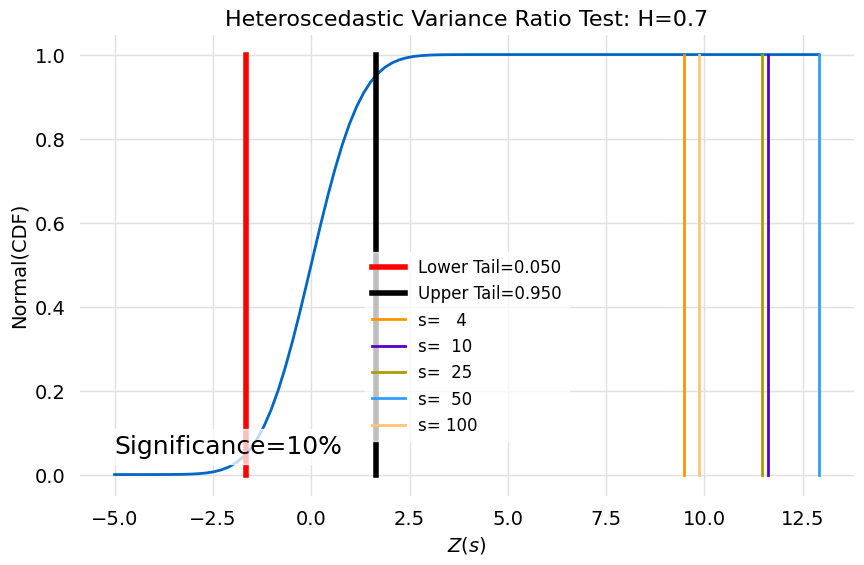

In [67]:
hetero_test_stat_plot(report, H_vals[1])

#### H=0.3

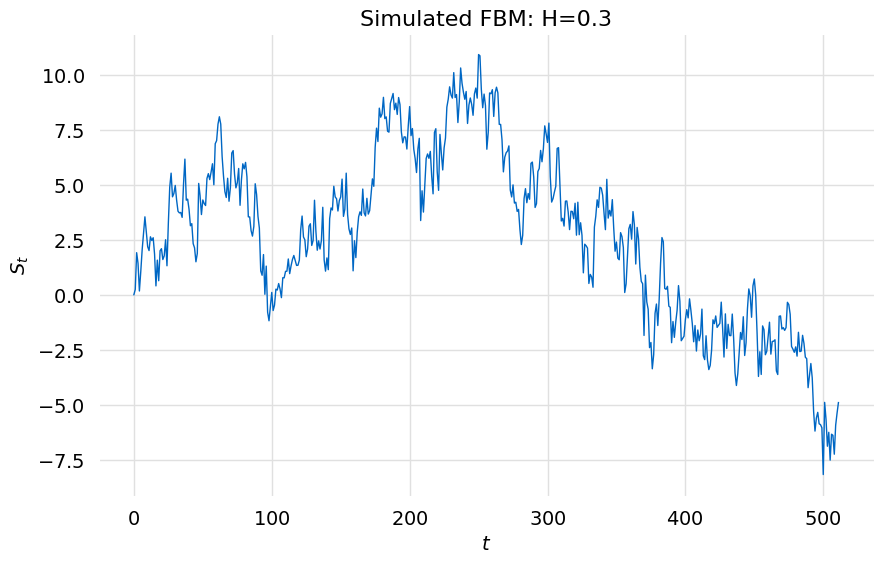

In [68]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [69]:
report, result = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.555 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.76  │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.722 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.125 │    0.034 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

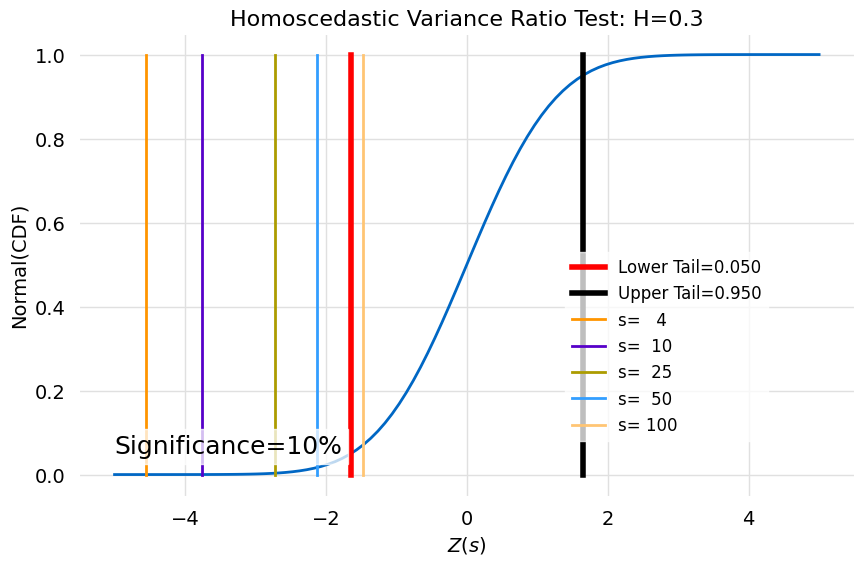

In [70]:
homo_test_stat_plot(report, H_vals[2])

In [71]:
report, result = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.559 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.809 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.748 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.169 │    0.03  │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

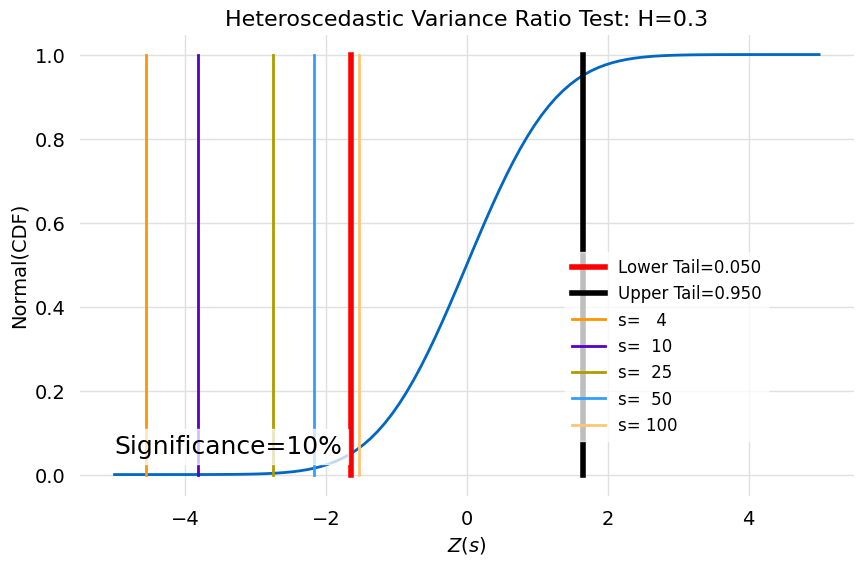

In [72]:
hetero_test_stat_plot(report, H_vals[2])

### Values Near H=0.5

In [73]:
npts = 2**9
s_vals = [2, 4, 10, 25, 50]
H_vals = [0.49, 0.45, 0.4, 0.51, 0.55]
t, samples = create(H_vals, npts)

#### H=0.49

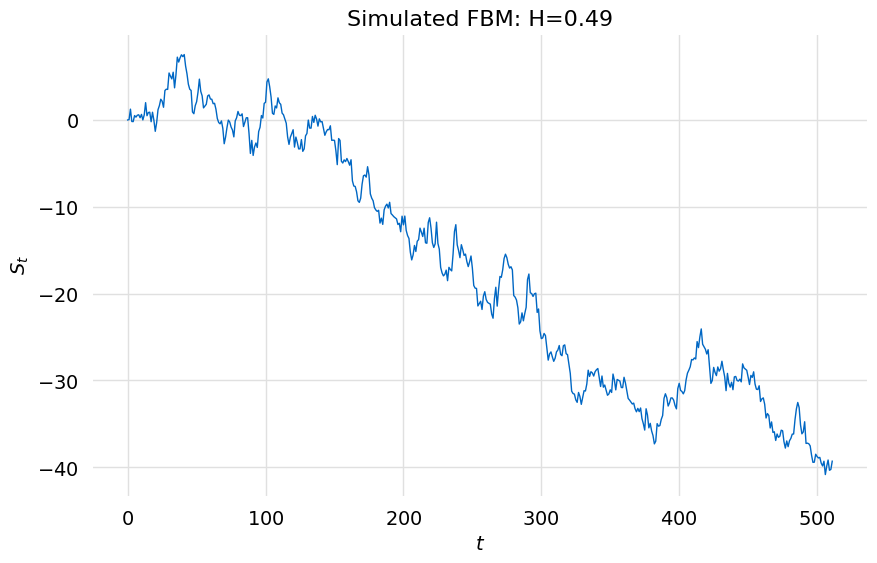

In [74]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [75]:
report, result = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.544 │    0.586 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.182 │    0.237 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.737 │    0.461 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.667 │    0.096 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

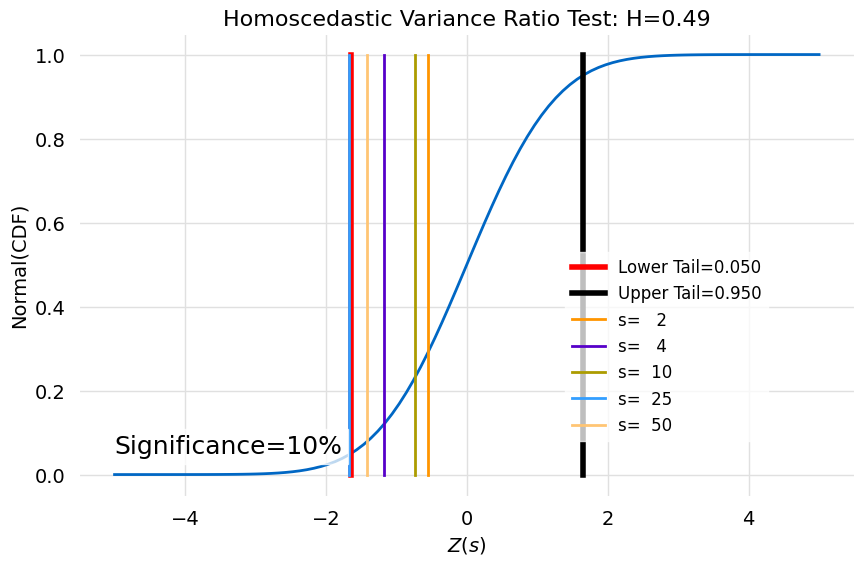

In [76]:
homo_test_stat_plot(report, H_vals[0])

In [77]:
report, result = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.559 │    0.576 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.177 │    0.239 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.738 │    0.46  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.664 │    0.096 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

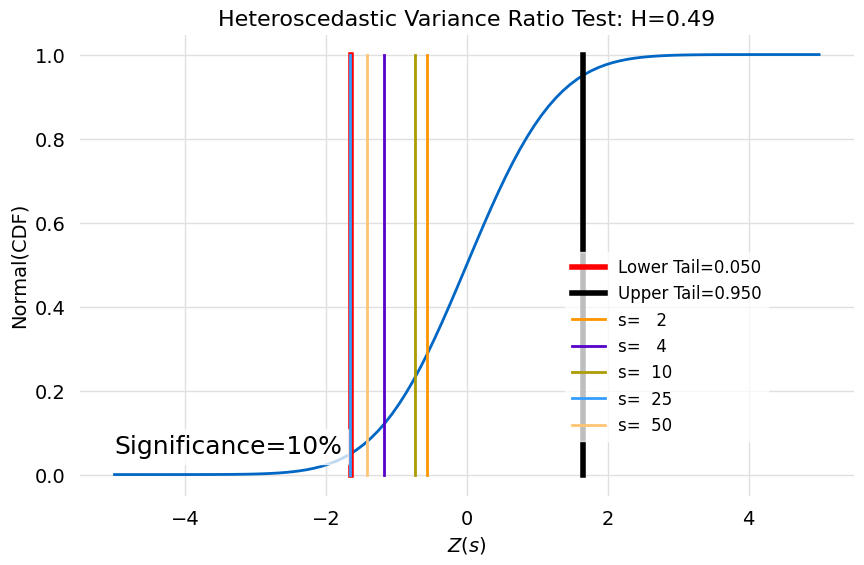

In [78]:
hetero_test_stat_plot(report, H_vals[0])

#### H=0.45

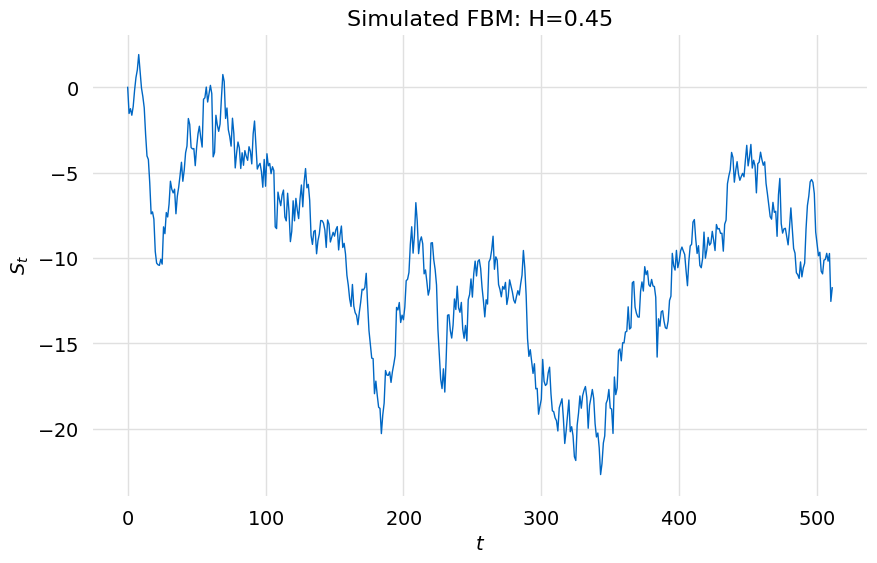

In [79]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [80]:
report, result = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.796 │    0.426 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.123 │    0.261 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.331 │    0.183 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.242 │    0.214 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

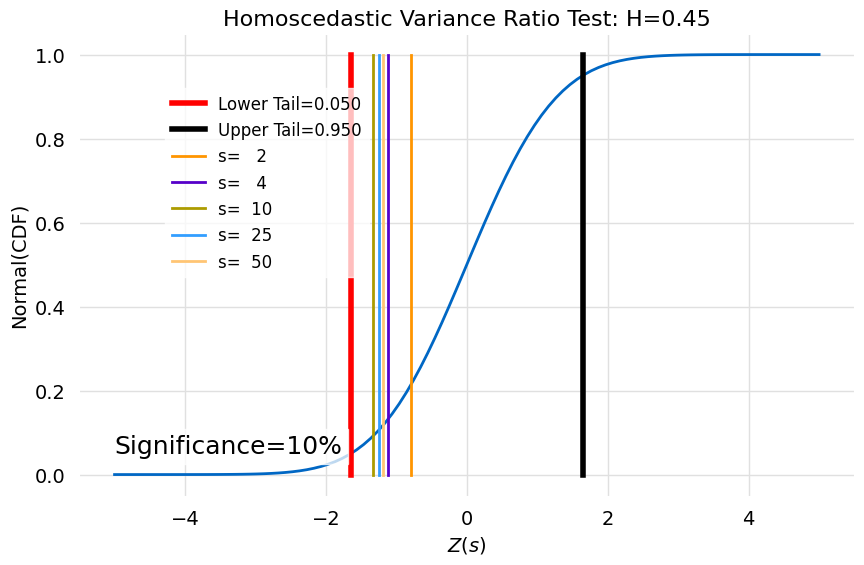

In [81]:
homo_test_stat_plot(report, H_vals[1])

In [82]:
report, result = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.862 │    0.388 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.183 │    0.237 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.399 │    0.162 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.273 │    0.203 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

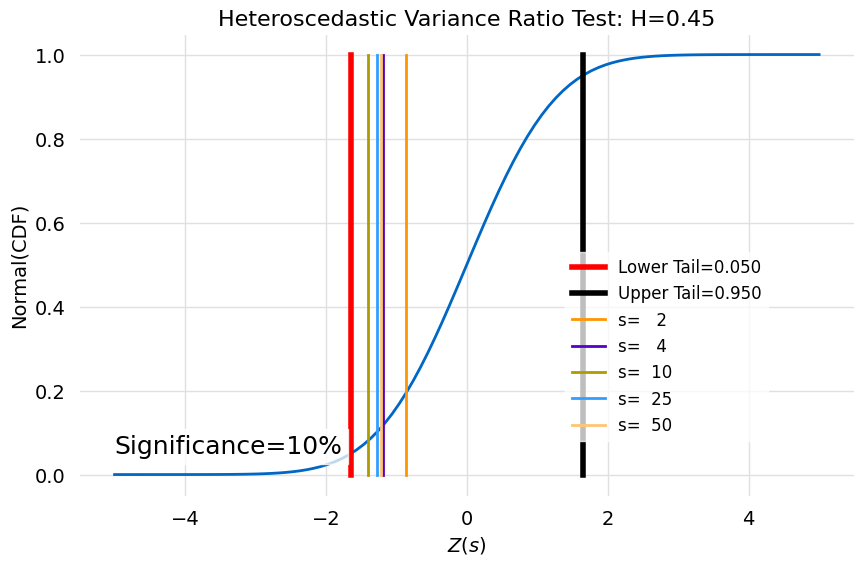

In [83]:
hetero_test_stat_plot(report, H_vals[1])

#### H=0.4

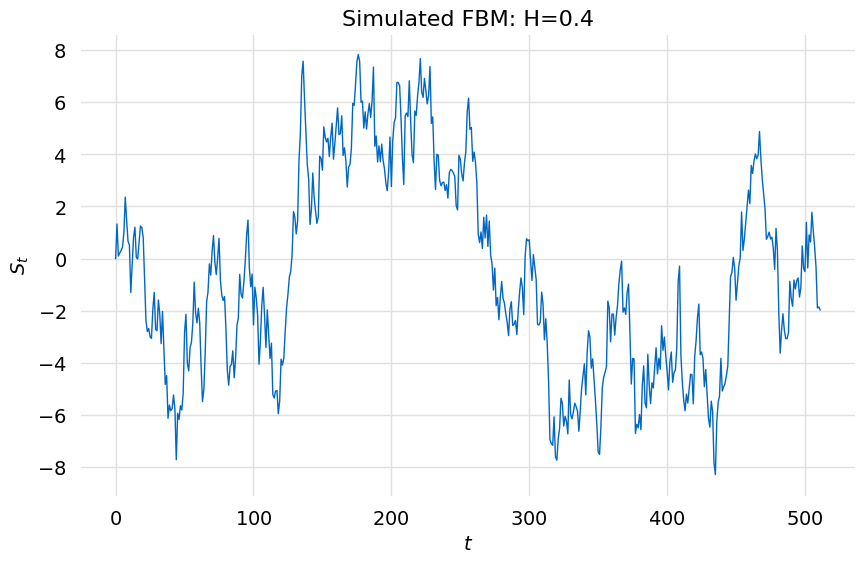

In [84]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [85]:
report, result = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.558 │    0.577 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.531 │    0.126 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.49  │    0.136 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.699 │    0.089 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

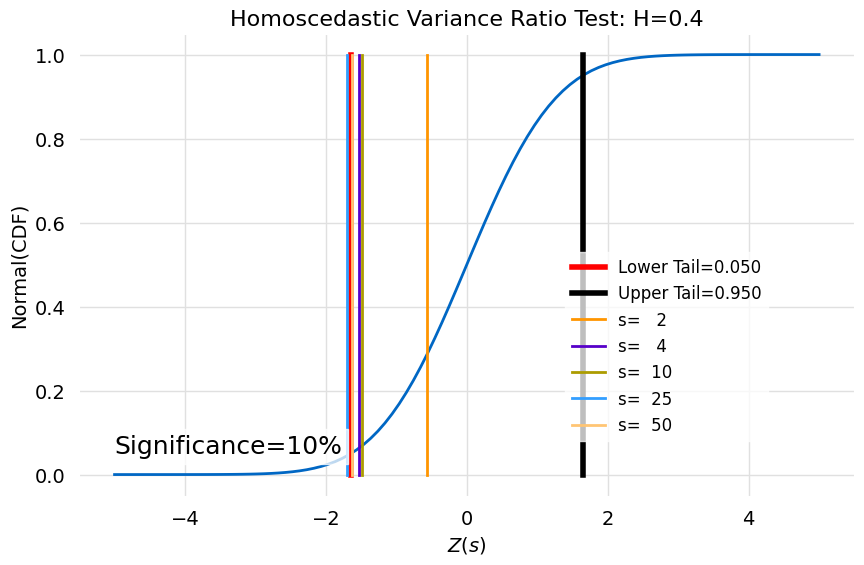

In [86]:
homo_test_stat_plot(report, H_vals[2])

In [87]:
report, result = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.594 │    0.553 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -1.586 │    0.113 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.535 │    0.125 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -1.738 │    0.082 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

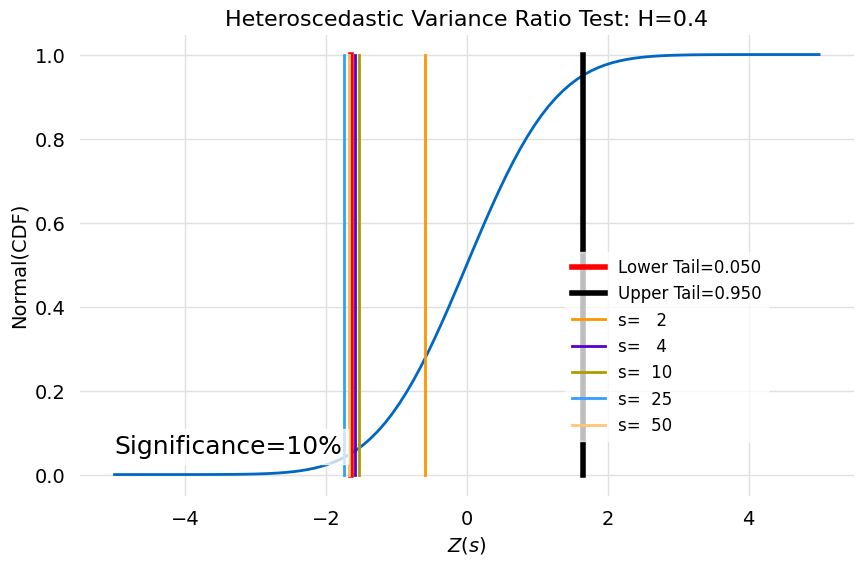

In [88]:
hetero_test_stat_plot(report, H_vals[2])

#### H=0.51

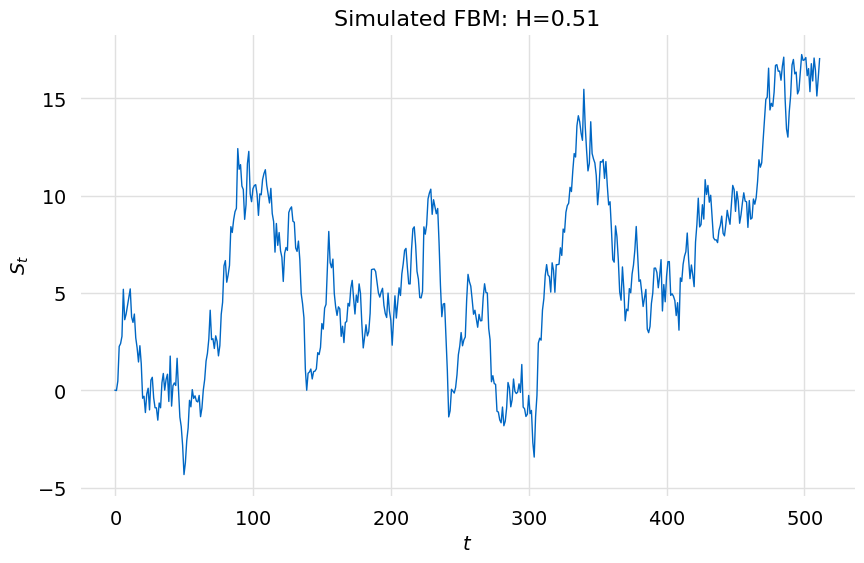

In [89]:
title = f"Simulated FBM: H={H_vals[3]}"
curve(samples[3], t[3], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [90]:
report, result = fbm.compute_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.368 │    0.713 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -0.187 │    0.852 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.006 │    0.995 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.46  │    0.645 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

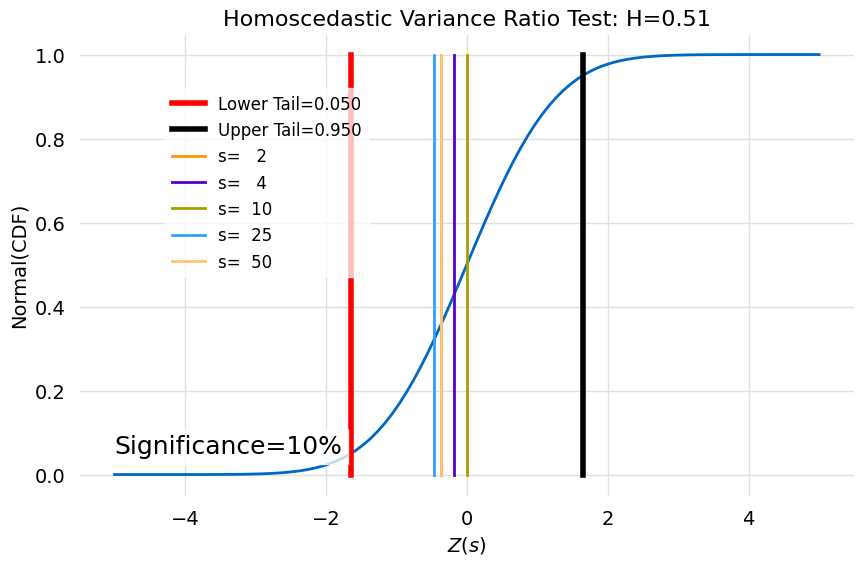

In [91]:
homo_test_stat_plot(report, H_vals[3])

In [92]:
report, result = fbm.compute_hetero_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -0.357 │    0.721 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -0.185 │    0.853 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.006 │    0.995 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.468 │    0.64  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

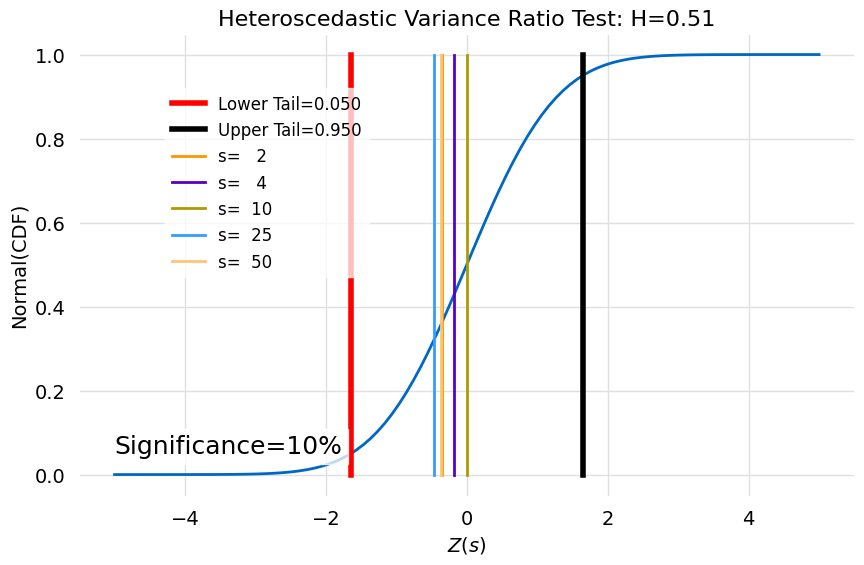

In [93]:
hetero_test_stat_plot(report, H_vals[3])

#### H=0.55

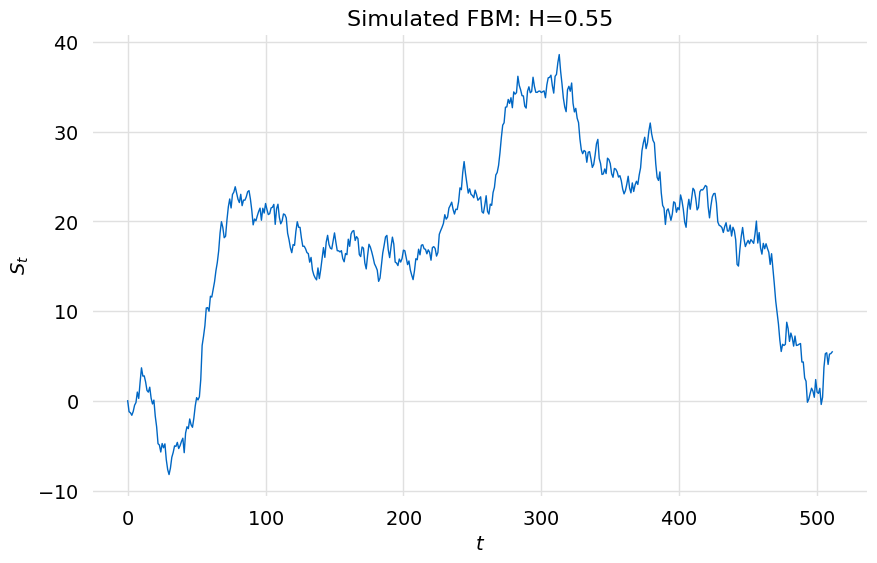

In [94]:
title = f"Simulated FBM: H={H_vals[4]}"
curve(samples[4], t[4], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [95]:
report, result = fbm.compute_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  3.041 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  2.504 │    0.012 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.191 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  4.095 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  3

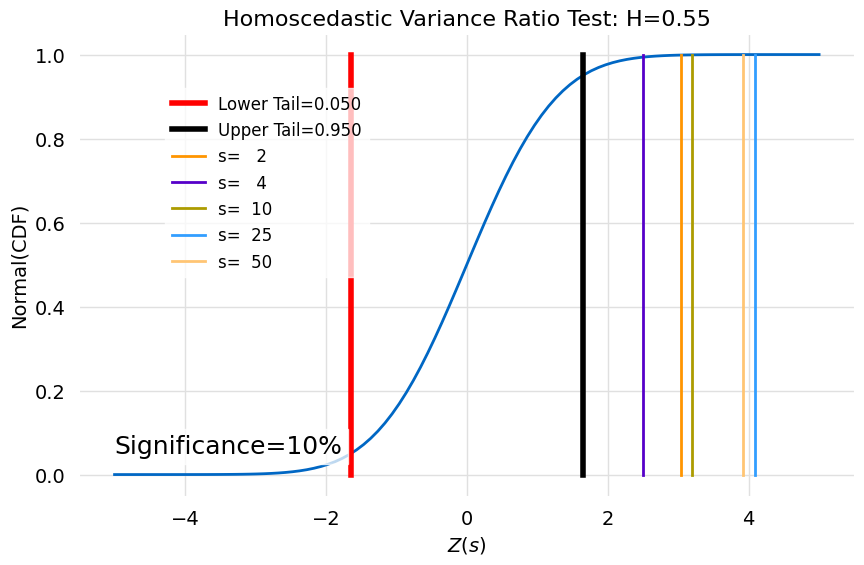

In [96]:
homo_test_stat_plot(report, H_vals[4])

In [97]:
report, result = fbm.compute_hetero_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  2.973 │    0.003 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  2.444 │    0.015 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  3.141 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  4.088 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  3

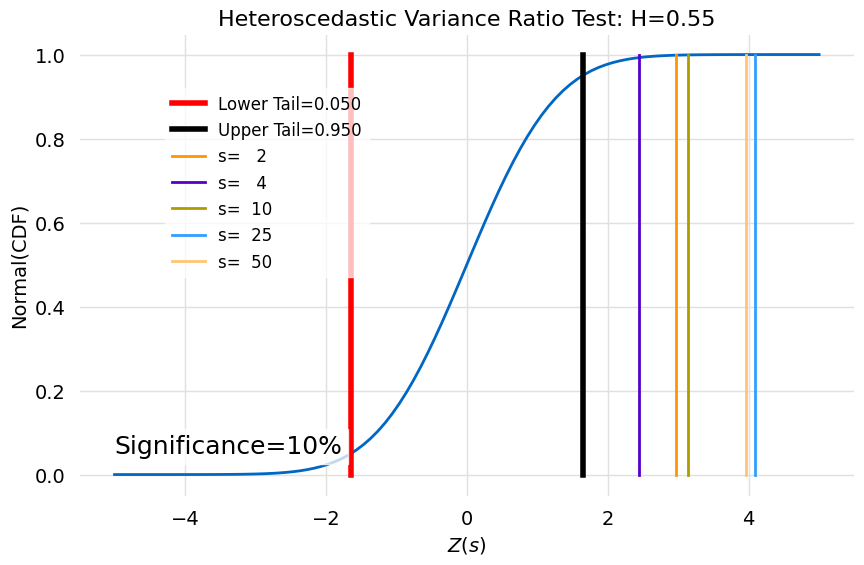

In [98]:
hetero_test_stat_plot(report, H_vals[4])

## Variance Ratio Test

Here the performance of the variance ratio test is evaluated. In the previous analysis the performance of the homoscedastic test was not significantly different</br>
than the heteroscedastic test. Since the homoscedastic test is much faster it is used. The values of the variance ratio test statistic for $0 < H < \frac{1}{2}$, $H=\frac{1}{2}$</br>
and $\frac{1}{2} < H < 1$ respectively satisfy $Z(s) < 0$, $Z(s) = 0$ and $Z(s) > 0$. This follows from the variance ratio, $\text{VR}(s)$ satisfying $0 < \text{VR}(s) < 1$, $\text{VR}(s)=1$ and $\text{VR}(s) > 1$</br>
in that same regions. Plots of $Z(s)$ for these regions are shown below. It is seen for $0 < H < \frac{1}{2}$ that $Z(s)$ is an increasing function of $s$ and for $\frac{1}{2} < H < 1$</br>
$Z(s)$ has a more complex behavior but is increasing for smaller values of $s$. It follows that eventually for some value of $s$ the test will likely fail. This makes interpreting the tests</br> 
results somewhat difficult. In the previous analysis where $\text{VR}(s)$ was compared to $\sigma s^{2H-1}$ it was seen that for a series with $2^9$ points the the two values agreed well for</br>
up to $s=2^8$. This motivates evaluating $Z(s)$ in regions where it is always increasing using a sequence of values of $s$ satisfying $s \le 25$. For this range the agreement between $\text{VR}(s)$</br>
and $\sigma s^{2H-1}$ was best. $Z(s)$ is evaluated for each $s$ and the result is pass if at least one test passes and failed otherwise.

### $H \le \frac{1}{2}$

In [99]:
npts = 2**9
s_min=2.0
s_max=npts/2
s_npts=int(s_max - s_min + 1)

In [100]:
H_vals = [0.1, 0.2, 0.3, 0.4, 0.5]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

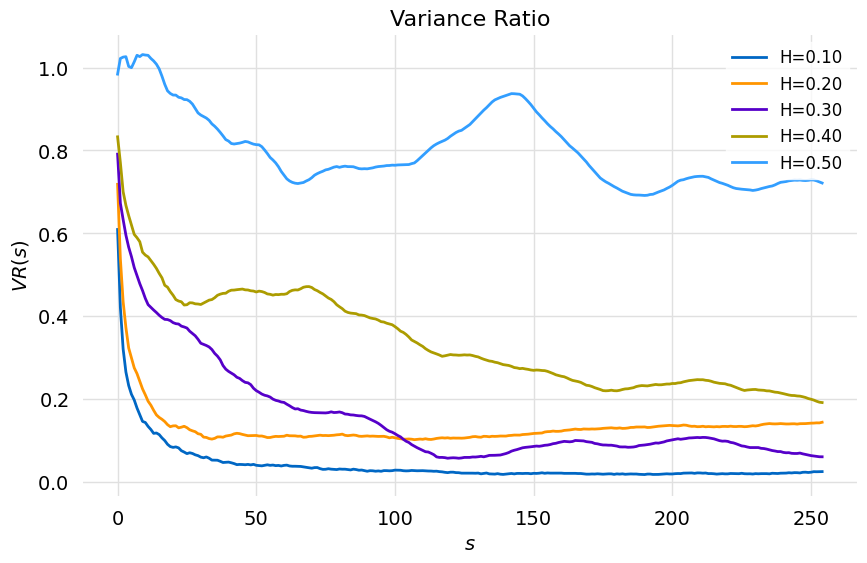

In [101]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H \ge \frac{1}{2}$

In [102]:
H_vals = [0.5, 0.6, 0.7, 0.8, 0.89]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

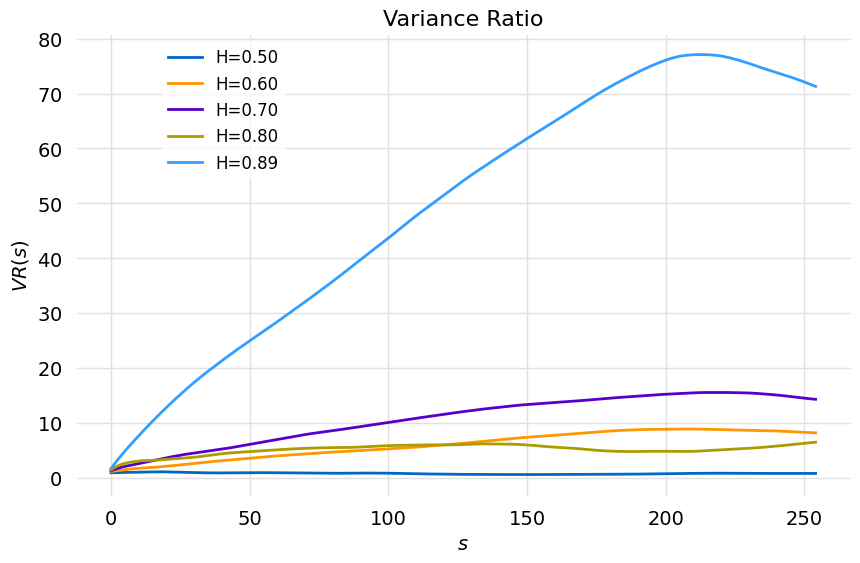

In [103]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H = 0.5$

Here a two tailed test for brownian motion is performed. This test is successful if the result is **PASSED**

In [104]:
H=0.5
t, samples = fbm.create_fft_source(H=H, npts=npts)
report, result = fbm.compute_vr_test(samples, HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.094 │    0.925 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.616 │    0.538 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.925 │    0.355 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.86  │    0.39  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  0

In [105]:
result.dict

{'Status': True,
 'HypothesisType': <HypothesisType.TWO_TAIL: 'TWO_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.BM: 'BM'>,
 'Description': 'Brownian Motion Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': 0.09386141579633366, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.9252192442113112, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s)$'}},
  {'Status': True,
   'Statistic': {'Value': 0.6162680298809926, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.5377176353694164, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s)$'

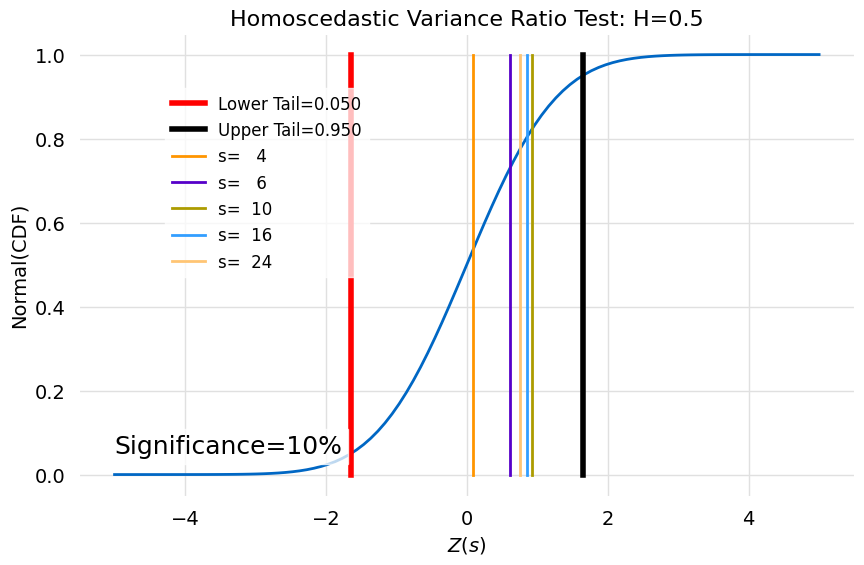

In [106]:
homo_test_stat_plot(report, H)

In [107]:
report, result = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
report.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.094 │    0.463 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.616 │    0.269 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.925 │    0.177 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.86  │    0.195 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  0.762 │    0.223 │ Pas

In [108]:
result.dict

{'Status': False,
 'HypothesisType': <HypothesisType.UPPER_TAIL: 'UPPER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.FBM_AUTO_CORR: 'AUTO_CORR'>,
 'Description': 'Autocorrelation Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': 0.09386141579633366, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.4626096221056556, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': None,
   'Upper Critical Value': {'Value': 1.2815515655446004, 'Label': '$Z_U(s)$'}},
  {'Status': True,
   'Statistic': {'Value': 0.6162680298809926, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.2688588176847082, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': None,
   'Upper Critical Value': {'Value': 1.2815515655446004, 'Label': '$Z_U(s)$'}},
  {'Status': True,
   'Statistic': {'Value': 0.9251087853390655, 'L

In [109]:
report, result = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
report.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.094 │    0.537 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.616 │    0.731 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.925 │    0.823 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.86  │    0.805 │ Passed   │
├─────┼────────┼──────────┼───────

In [110]:
result.dict

{'Status': False,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.FBM_NEG_AUTO_CORR: 'NEG_AUTO_CORR'>,
 'Description': 'Negative Autocorrelation Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': 0.09386141579633366, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.5373903778943444, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.2815515655446004, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': 0.6162680298809926, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.7311411823152918, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.2815515655446004, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': 0.9

### $H = 0.35$

Here a lower tail test is performed for fractional brownian with $H<\frac{1}{2}$. The test is successful if the result is **Failed**.

In [111]:
H=0.35
t, samples = fbm.create_fft_source(H=H, npts=npts)
report, result = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
report.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.629 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -4.462 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.794 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -3.307 │    0     │ Failed   │
├─────┼────────┼──────────┼───────

In [112]:
result.dict

{'Status': True,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.FBM_NEG_AUTO_CORR: 'NEG_AUTO_CORR'>,
 'Description': 'Negative Autocorrelation Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': -4.629039753606167, 'Label': '$Z(s)$'},
   'PValue': {'Value': 1.8368262340121765e-06, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.2815515655446004, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Value': -4.461618437313362, 'Label': '$Z(s)$'},
   'PValue': {'Value': 4.067148408294425e-06, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.2815515655446004, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': None},
  {'Status': False,
   'Statistic': {'Val

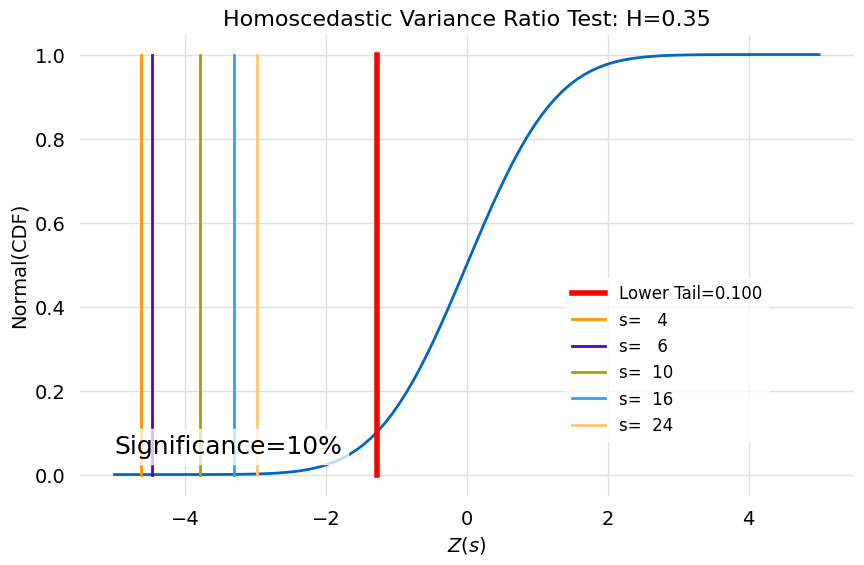

In [113]:
homo_test_stat_plot(report, H)

In [114]:
report, result = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
report.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.629 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -4.462 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.794 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -3.307 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2.984 │    0.999 │ Pas

In [115]:
result.dict

{'Status': False,
 'HypothesisType': <HypothesisType.UPPER_TAIL: 'UPPER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.FBM_AUTO_CORR: 'AUTO_CORR'>,
 'Description': 'Autocorrelation Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': -4.629039753606167, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.999998163173766, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': None,
   'Upper Critical Value': {'Value': 1.2815515655446004, 'Label': '$Z_U(s)$'}},
  {'Status': True,
   'Statistic': {'Value': -4.461618437313362, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.9999959328515917, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': None,
   'Upper Critical Value': {'Value': 1.2815515655446004, 'Label': '$Z_U(s)$'}},
  {'Status': True,
   'Statistic': {'Value': -3.7939527963732456, 'La

In [116]:
report, result = fbm.compute_vr_test(samples, HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.629 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -4.462 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.794 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -3.307 │    0.001 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -2

In [117]:
result.dict

{'Status': False,
 'HypothesisType': <HypothesisType.TWO_TAIL: 'TWO_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.BM: 'BM'>,
 'Description': 'Brownian Motion Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': -4.629039753606167, 'Label': '$Z(s)$'},
   'PValue': {'Value': 3.6736524680058835e-06, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s)$'}},
  {'Status': False,
   'Statistic': {'Value': -4.461618437313362, 'Label': '$Z(s)$'},
   'PValue': {'Value': 8.134296816564301e-06, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '

### $H = 0.6$

Here an upper tailed test for fractional brownian motion with $H > \frac{1}{2}$. The test is successful if the result is **Failed**.

In [118]:
H=0.6
t, samples = fbm.create_fft_source(H=H, npts=npts)
report, result = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
report.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.367 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  4.995 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  4.949 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  4.331 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  4.221 │        0 │ Fai

In [119]:
result.dict

{'Status': True,
 'HypothesisType': <HypothesisType.UPPER_TAIL: 'UPPER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.FBM_AUTO_CORR: 'AUTO_CORR'>,
 'Description': 'Autocorrelation Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': 5.367340283725578, 'Label': '$Z(s)$'},
   'PValue': {'Value': 3.9953106711898556e-08, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': None,
   'Upper Critical Value': {'Value': 1.2815515655446004, 'Label': '$Z_U(s)$'}},
  {'Status': False,
   'Statistic': {'Value': 4.994921583781663, 'Label': '$Z(s)$'},
   'PValue': {'Value': 2.942983932108234e-07, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': None,
   'Upper Critical Value': {'Value': 1.2815515655446004, 'Label': '$Z_U(s)$'}},
  {'Status': False,
   'Statistic': {'Value': 4.94892113886868

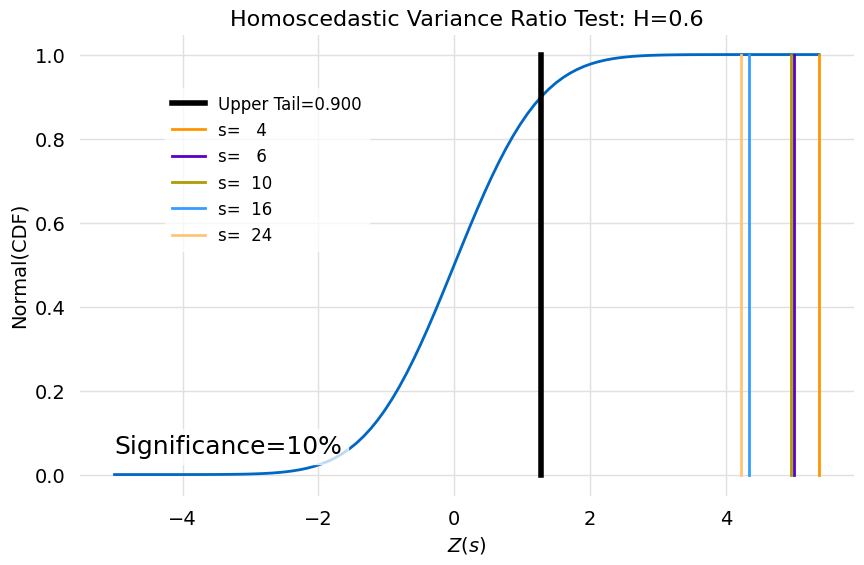

In [120]:
homo_test_stat_plot(report, H)

In [121]:
report, result = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
report.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.367 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  4.995 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  4.949 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  4.331 │        1 │ Passed   │
├─────┼────────┼──────────┼───────

In [122]:
result.dict

{'Status': False,
 'HypothesisType': <HypothesisType.LOWER_TAIL: 'LOWER_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.FBM_NEG_AUTO_CORR: 'NEG_AUTO_CORR'>,
 'Description': 'Negative Autocorrelation Test',
 'TestData': [{'Status': True,
   'Statistic': {'Value': 5.367340283725578, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.9999999600468933, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.2815515655446004, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': 4.994921583781663, 'Label': '$Z(s)$'},
   'PValue': {'Value': 0.9999997057016068, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.2815515655446004, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': None},
  {'Status': True,
   'Statistic': {'Value': 4.9489

In [123]:
report, result = fbm.compute_vr_test(samples, HypothesisTestType.BM)
report.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.367 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  4.995 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  4.949 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  4.331 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  4

In [124]:
result.dict

{'Status': False,
 'HypothesisType': <HypothesisType.TWO_TAIL: 'TWO_TAIL'>,
 'HypothesisTestType': <HypothesisTestType.BM: 'BM'>,
 'Description': 'Brownian Motion Test',
 'TestData': [{'Status': False,
   'Statistic': {'Value': 5.367340283725578, 'Label': '$Z(s)$'},
   'PValue': {'Value': 7.990621342379711e-08, 'Label': '$p-value$'},
   'Parameters': [{'Value': 4, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_U(s)$'}},
  {'Status': False,
   'Statistic': {'Value': 4.994921583781663, 'Label': '$Z(s)$'},
   'PValue': {'Value': 5.885967864216468e-07, 'Label': '$p-value$'},
   'Parameters': [{'Value': 6, 'Label': '$s$'}],
   'Significance': {'Value': 0.1, 'Label': '10%'},
   'Lower Critical Value': {'Value': -1.6448536269514729, 'Label': '$Z_L(s)$'},
   'Upper Critical Value': {'Value': 1.6448536269514722, 'Label': '$Z_